#<center> **FUNDAMENTOS DE PROGRAMACIÓN PARA LA CIENCIA DE DATOS E INTELIGENCIA ARTIFICIAL** </center>
## <center> **Especialización Ciencia de Datos e Inteligencia Artificial - ECDIA** </center>
###  <center> Universidad Tecnológica - UTEC </center>
### <center> Abril Ocampo, Emiliano Braña, Federico Lima, Florencia Franco</center>

# **Etapa I: Problemática y conjunto de datos**

La primera etapa de un análisis exploratorio de datos consiste en comprender y delimitar la problemática central que motiva el estudio, así como en identificar, describir y evaluar el conjunto de datos que se utilizará para abordarla. Esta etapa es crítica, ya que establece el contexto analítico, define los objetivos y marca las directrices para las siguientes fases del análisis.


## **Definición y contextualización de la Problemática**





En esta fase, se plantea con claridad el problema que se busca resolver o comprender mediante el análisis de datos. Esto implica plantear un objetivo y responder preguntas clave.

* Objetivo
* Preguntas clave

Se trata de un dataset acerca de depresión estudiantil. Los datos fueron
generados a través de encuestas anonimizadas en diferentes instituciones educativas de la India. El dataset original se puede obtener en: https://www.openml.org/search?type=data&status=active&id=46753&sort=runs.

El dataset utilizado en este análisis se obtiene de Kaggle: https://www.kaggle.com/datasets/adilshamim8/student-depression-dataset.  Contiene información demográfica, de performance académico, estilo de vida y antecedentes de salud mental. Esta diversidad de variables permite un análisis multidimensional de los factores asociados a la depresión en el ámbito estudiantil, ofreciendo una base sólida para identificar perfiles de riesgo y orientar intervenciones y campañas de prevención y apoyo adaptadas a las necesidades de distintos subgrupos dentro del sistema educativo. No contiene referencias temporales que permita identificar cuándo fueron relevados los datos.

**Objetivo**

* Analizar y caracterizar los perfiles de estudiantes con mayor riesgo de depresión, integrando variables demográficas, académicas, de estilo de vida y antecedentes de salud mental, con el fin de diseñar campañas de comunicación e intervención focalizadas y efectivas.

**Preguntas clave**

* ¿Cómo se relacionan los factores demográficos como la edad, el género y la zona geográfica, en la prevalencia de la depresión en estudiantes?

* ¿Cómo es el impacto comparativo de los factores académicos (rendimiento, presión académica y satisfacción laboral) frente a hábitos y estilos de vida (hábitos de sueño, de alimentación) en la aparición de la depresión en los estudiantes?

* ¿De qué manera los antecedentes personales y familiares en salud mental contribuyen al riesgo y la manifestación de la depresión en el ámbito estudiantil?

* ¿Existen subgrupos específicos dentro de la población estudiantil que presenten un riesgo significativamente mayor de desarrollar depresión, y cuáles son sus características distintivas?


## **Descripción y calidad de los datos**

Una vez definida la problemática, se describe el conjunto de datos que será utilizado, evaluando su calidad para garantizar que estos permiten alcanzar los objetivos planteados en la problemática.

* Se evalúan las dimensiones definidas para la calidad de datos, respondiendo las siguientes preguntas:
  * **Completitud:** ¿Faltan datos?
  * **Validez:** ¿Cumplen con los formatos esperados?
  * **Precisión:** ¿Son correctos y fiables?
  * **Consistencia:** ¿Coinciden los datos entre fuentes?
  * **Relevancia:** ¿Los datos son pertinentes para tener resultados concluyentes del problema en estudio?
  * **Unicidad:** ¿Ausencia de registros duplicados?
  * **Integridad:** ¿Datos completos y sin corrupción?

In [1]:
# Importo librerías
import kagglehub
from google.colab import files, drive
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.graphics.mosaicplot import mosaic
from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')
!pip install prince==0.7.1
from prince import MCA
from scipy import stats # Import the stats module from scipy
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import euclidean_distances, manhattan_distances, cosine_similarity
from sklearn.metrics import jaccard_score

In [2]:
## Cargo la base
path = kagglehub.dataset_download("adilshamim8/student-depression-dataset")

print("Path to dataset files:", path)

## Leo el archivo csv

csvFile = pd.read_csv(path + '/student_depression_dataset.csv')
print(csvFile)

Path to dataset files: /kaggle/input/student-depression-dataset
           id  Gender   Age           City Profession  Academic Pressure  \
0           2    Male  33.0  Visakhapatnam    Student                5.0   
1           8  Female  24.0      Bangalore    Student                2.0   
2          26    Male  31.0       Srinagar    Student                3.0   
3          30  Female  28.0       Varanasi    Student                3.0   
4          32  Female  25.0         Jaipur    Student                4.0   
...       ...     ...   ...            ...        ...                ...   
27896  140685  Female  27.0          Surat    Student                5.0   
27897  140686    Male  27.0       Ludhiana    Student                2.0   
27898  140689    Male  31.0      Faridabad    Student                3.0   
27899  140690  Female  18.0       Ludhiana    Student                5.0   
27900  140699    Male  27.0          Patna    Student                4.0   

       Work Pressure  C

# **Etapa II: Limpieza y preprocesamiento de los datos**

La segunda etapa del análisis exploratorio de datos se centra en la limpieza y el preprocesamiento del conjunto de datos. Esta fase es esencial para garantizar la coherencia y utilidad analítica de los datos, ya que los análisis y visualizaciones posteriores dependerán directamente de la confiabilidad de esta información.

## **Limpieza del conjunto de datos**

La limpieza de datos implica la detección y corrección de inconsistencias, errores o valores problemáticos que pueden afectar la interpretación del análisis.

* Verificación de valores faltantes y datos nulos
  * Busca duplicados y determina si representan errores o datos válidos
  * Corrige formatos inconsistentes y estandariza columnas similares
  * Verifica la consistencia de formatos (fechas, números, categóricas)
  * Identifica posibles errores de entrada o inconsistencias lógicas
  * Identifica y cuantifica valores faltantes en cada columna

* Imputación de datos faltantes
  * Detecta valores atípicos (outliers) mediante técnicas estadísticas
  * Implementa métodos diferentes de imputación para valores faltantes
  * Justifica cada decisión tomada (eliminación vs. imputación)
  * Maneja los valores atípicos utilizando al menos dos enfoques diferentes

* Verificación de tipos de atributos
  * Transformación y codificación de datos
  * Aplica transformaciones apropiadas a variables numéricas (log, raíz cuadrada, conversión de unidades, etc.)
  * Codifica variables categóricas utilizando métodos adecuados (one-hot, label encoding)
  * Normaliza o estandariza variables numéricas según sea necesario
  * Crea nuevas variables derivadas que puedan ser útiles para análisis.



In [3]:
# Mostrar los tipos de datos de cada columna
print(csvFile.dtypes)

id                                         int64
Gender                                    object
Age                                      float64
City                                      object
Profession                                object
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                            object
Dietary Habits                            object
Degree                                    object
Have you ever had suicidal thoughts ?     object
Work/Study Hours                         float64
Financial Stress                          object
Family History of Mental Illness          object
Depression                                 int64
dtype: object


In [4]:
# Veo la información de la base
csvFile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [5]:
#Tamaño del conjunto de datos
csvFile.shape

(27901, 18)

In [6]:
#Identificación y suma de datos nulos
csvFile.isnull().sum()

,0
id,0
Gender,0
Age,0
City,0
Profession,0
Academic Pressure,0
Work Pressure,0
CGPA,0
Study Satisfaction,0
Job Satisfaction,0


In [7]:
# Identificación de datos duplicados
csvFile.duplicated().sum()

np.int64(0)

In [8]:
# Identificación de datos duplicados por filas de acuerdo a cada columna
duplicate_rows = csvFile[csvFile.duplicated(keep=False)]
print(duplicate_rows)

Empty DataFrame
Columns: [id, Gender, Age, City, Profession, Academic Pressure, Work Pressure, CGPA, Study Satisfaction, Job Satisfaction, Sleep Duration, Dietary Habits, Degree, Have you ever had suicidal thoughts ?, Work/Study Hours, Financial Stress, Family History of Mental Illness, Depression]
Index: []


In [9]:
duplicadosID = csvFile[csvFile.duplicated(subset=['id'], keep=False)]
duplicadosID

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression


In [10]:
# Principales estadisticos

csvFile.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,1.000000


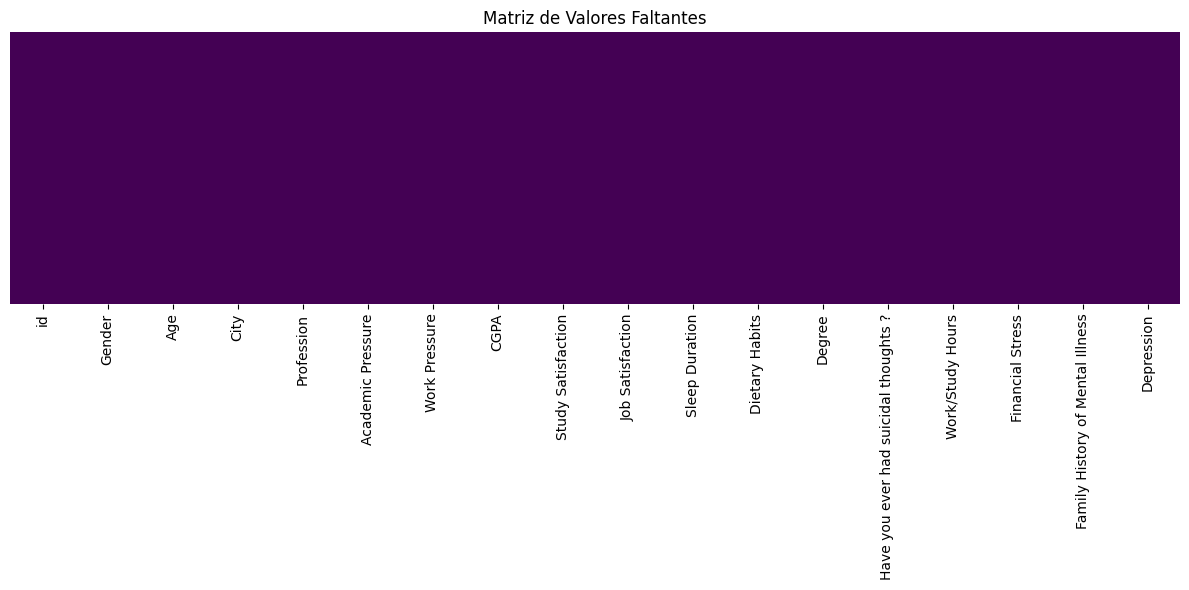

In [11]:
# Visualizamos los valores faltantes
plt.figure(figsize=(12, 6))
sns.heatmap(csvFile.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Matriz de Valores Faltantes')
plt.tight_layout()


## **Preprocesamiento de datos**

* Conversión de tipos de datos (transformar fechas a tipo datetime, variables categóricas a tipo category, etc.).

* Estandarización o normalización de variables numéricas, especialmente si se utilizarán métodos sensibles a escalas.
Codificación de variables categóricas, como one-hot encoding o label encoding.

* Creación de nuevas variables derivadas (features), a partir de combinaciones o transformaciones de las existentes.

* Segmentación temporal, si se trabaja con series de tiempo (extraer año, mes, día de una fecha).

* Selección de subconjuntos de (variables) características
    * Conjunto de datos en formato .csv preprocesado

Es fundamental llevar un registro claro y reproducible de todos los cambios realizados durante esta etapa. Esto no solo garantiza la transparencia del análisis, sino que facilita su replicación, validación y mejora continua.

In [12]:
## Creo una copia del df
csvFile_copia = csvFile.copy()

In [13]:
#Veo los valores que aparecen en las ciudades
pd.unique(csvFile_copia['City'])

## El valor 3.0 no corresponde a una ciudad, 'less than five' tampoco

array(['Visakhapatnam', 'Bangalore', 'Srinagar', 'Varanasi', 'Jaipur',
       'Pune', 'Thane', 'Chennai', 'Nagpur', 'Nashik', 'Vadodara',
       'Kalyan', 'Rajkot', 'Ahmedabad', 'Kolkata', 'Mumbai', 'Lucknow',
       'Indore', 'Surat', 'Ludhiana', 'Bhopal', 'Meerut', 'Agra',
       'Ghaziabad', 'Hyderabad', 'Vasai-Virar', 'Kanpur', 'Patna',
       'Faridabad', 'Delhi', 'Saanvi', 'M.Tech', 'Bhavna', "'Less Delhi'",
       'City', '3.0', "'Less than 5 Kalyan'", 'Mira', 'Harsha', 'Vaanya',
       'Gaurav', 'Harsh', 'Reyansh', 'Kibara', 'Rashi', 'ME', 'M.Com',
       'Nalyan', 'Mihir', 'Nalini', 'Nandini', 'Khaziabad'], dtype=object)

In [14]:
## hay nombres que no corresponden a una ciudad por lo que vemos por ciudad cuantas filas hay

city_counts = csvFile_copia.groupby('City')['id'].count()

city_counts

,id
City,
'Less Delhi',1
'Less than 5 Kalyan',1
3.0,1
Agra,1094
Ahmedabad,951
Bangalore,767
Bhavna,2
Bhopal,934
Chennai,885


In [15]:
#Veo los valores que aparecen en las ciudad
# recategorizo algunos valores que no son nombres de ciudades a desconocido
csvFile_copia['City'] = csvFile_copia['City'].replace(["'Less than 5 Kalyan'", '3.0', 'City','M.Com', "'Less Delhi'", 'M.Tech', 'ME'], 'Desconocido')

print(pd.unique(csvFile_copia['City']))

['Visakhapatnam' 'Bangalore' 'Srinagar' 'Varanasi' 'Jaipur' 'Pune' 'Thane'
 'Chennai' 'Nagpur' 'Nashik' 'Vadodara' 'Kalyan' 'Rajkot' 'Ahmedabad'
 'Kolkata' 'Mumbai' 'Lucknow' 'Indore' 'Surat' 'Ludhiana' 'Bhopal'
 'Meerut' 'Agra' 'Ghaziabad' 'Hyderabad' 'Vasai-Virar' 'Kanpur' 'Patna'
 'Faridabad' 'Delhi' 'Saanvi' 'Desconocido' 'Bhavna' 'Mira' 'Harsha'
 'Vaanya' 'Gaurav' 'Harsh' 'Reyansh' 'Kibara' 'Rashi' 'Nalyan' 'Mihir'
 'Nalini' 'Nandini' 'Khaziabad']


In [16]:
# Cuento cuantos quedaron con la ciudad 'Desconocido'

city_counts =  csvFile_copia[csvFile_copia['City'] == 'Desconocido']['id'].count()

city_counts

np.int64(8)

In [17]:
# genero un mapeo con las regiones de la india, observar que hay valores que no correponden a ningua ciudad y se recatagorizan como desconocido
region_mapping = {
    "Norte": [
        "Delhi", "Ghaziabad", "Agra", "Meerut", "Ludhiana", "Jaipur", "Kanpur", "Lucknow", "Srinagar", "Faridabad", "Khaziabad"
    ],
    "Sur": [
        "Bangalore", "Chennai", "Hyderabad", "Visakhapatnam"
    ],
    "Este": [
        "Kolkata", "Patna", "Varanasi"
    ],
    "Oeste": [
        "Mumbai", "Pune", "Surat", "Ahmedabad", "Rajkot", "Vadodara", "Nashik", "Thane", "Kalyan", "Vasai-Virar"
    ],
    "Centro": [
        "Indore", "Bhopal", "Nagpur"
    ],
    "Desconocido": [
        "Saanvi", "Desconocido", "Bhavna", "Mira", "Harsha", "Vaanya", "Gaurav", "Harsh", "Reyansh", "Kibara", "Rashi", "Nalyan", "Mihir", "Nalini", "Nandini"
    ]
}

In [18]:
# genero una funcion que aplica el mapping a las ciudades del df,
# retornando region y chequeo que quedo ok
def categorize_city(city):
    for region, cities in region_mapping.items():
        if city in cities:
            return region
    return "Desconocido"

csvFile_copia['Region'] = csvFile_copia['City'].apply(categorize_city)

print(pd.unique(csvFile_copia['Region']))

['Sur' 'Norte' 'Este' 'Oeste' 'Centro' 'Desconocido']


In [19]:
# Veo los valores que hay de genero

pd.unique(csvFile_copia['Gender'])

array(['Male', 'Female'], dtype=object)

In [20]:
# veo los valores distintos de profession

pd.unique(csvFile_copia['Profession'])

array(['Student', "'Civil Engineer'", 'Architect', "'UX/UI Designer'",
       "'Digital Marketer'", "'Content Writer'",
       "'Educational Consultant'", 'Teacher', 'Manager', 'Chef', 'Doctor',
       'Lawyer', 'Entrepreneur', 'Pharmacist'], dtype=object)

In [21]:
# veo los distintos valores de Dietary Habits

pd.unique(csvFile_copia['Dietary Habits'])

array(['Healthy', 'Moderate', 'Unhealthy', 'Others'], dtype=object)

In [22]:
# veo los distintos valores de Family History of Mental Illness

pd.unique(csvFile_copia['Family History of Mental Illness'])

array(['No', 'Yes'], dtype=object)

In [23]:
# veo los distintos valores de Sleep Duration

pd.unique(csvFile_copia['Sleep Duration'])

array(["'5-6 hours'", "'Less than 5 hours'", "'7-8 hours'",
       "'More than 8 hours'", 'Others'], dtype=object)

In [24]:
# veo los distintos valores de  Degree

pd.unique(csvFile_copia['Degree'])

array(['B.Pharm', 'BSc', 'BA', 'BCA', 'M.Tech', 'PhD', "'Class 12'",
       'B.Ed', 'LLB', 'BE', 'M.Ed', 'MSc', 'BHM', 'M.Pharm', 'MCA', 'MA',
       'B.Com', 'MD', 'MBA', 'MBBS', 'M.Com', 'B.Arch', 'LLM', 'B.Tech',
       'BBA', 'ME', 'MHM', 'Others'], dtype=object)

In [25]:
# Cuento cuantos quedaron con la ciudad 'Desconocido'

degree_counts =  csvFile_copia[csvFile_copia['Degree'] == "'Class 12'"]['id'].count()

degree_counts

np.int64(6080)

In [26]:
## Creamos subset de degree

# Mapeo de los degrees

map_education = {
    # High School
    "'Class 12'": 'High School',

    # Bachelor's
    'B.Pharm': 'Bachelor',
    'BSc': 'Bachelor',
    'BA': 'Bachelor',
    'BCA': 'Bachelor',
    'B.Ed': 'Bachelor',
    'LLB': 'Bachelor',
    'BE': 'Bachelor',
    'BHM': 'Bachelor',
    'B.Com': 'Bachelor',
    'B.Arch': 'Bachelor',
    'B.Tech': 'Bachelor',
    'BBA': 'Bachelor',

    # Master's
    'M.Tech': 'Master',
    'M.Ed': 'Master',
    'MSc': 'Master',
    'M.Pharm': 'Master',
    'MCA': 'Master',
    'MA': 'Master',
    'MBA': 'Master',
    'M.Com': 'Master',
    'ME': 'Master',
    'MHM': 'Master',
    'LLM': 'Master',

    # PhD
    'PhD': 'PhD',
    'MD': 'PhD',
    'MBBS': 'PhD',

    # Otros
    'Others': 'Others'
}

# Hago la nueva columna

# Nueva columna con la recategorización
csvFile_copia['Degree_level'] = csvFile_copia['Degree'].map(map_education)


In [27]:
# veo el head del data set

csvFile_copia.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,Region,Degree_level
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1,Sur,Bachelor
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0,Sur,Bachelor
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0,Norte,Bachelor
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1,Este,Bachelor
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0,Norte,Master


In [28]:
# veo los valores distintos de Have you ever had suicidal thoughts ?

pd.unique(csvFile_copia['Have you ever had suicidal thoughts ?'])

array(['Yes', 'No'], dtype=object)

In [29]:
# Cuento cuantos son estudiantes

pd.unique(csvFile_copia['Profession'])

array(['Student', "'Civil Engineer'", 'Architect', "'UX/UI Designer'",
       "'Digital Marketer'", "'Content Writer'",
       "'Educational Consultant'", 'Teacher', 'Manager', 'Chef', 'Doctor',
       'Lawyer', 'Entrepreneur', 'Pharmacist'], dtype=object)

In [30]:
profession_counts = csvFile_copia.groupby('Profession')['id'].count()

profession_counts

,id
Profession,
'Civil Engineer',1
'Content Writer',2
'Digital Marketer',3
'Educational Consultant',1
'UX/UI Designer',1
Architect,8
Chef,2
Doctor,2
Entrepreneur,1


In [31]:
# Borramos los registros que no sean estudiantes para quedarnos con una muestra limpia

csvFile_copia = csvFile_copia[csvFile_copia["Profession"] == 'Student']

csvFile_copia.shape

(27870, 20)

In [32]:
# Quitamos las columnas que no estan asociadas con estudiantes

csvFile_copia.drop('Work Pressure', axis = 'columns', inplace = True)

csvFile_copia.drop('Job Satisfaction', axis = 'columns', inplace = True)

csvFile_copia.shape

(27870, 18)

In [33]:
csvFile_copia.head()

,id,Gender,Age,City,Profession,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,Region,Degree_level
0,2,Male,33.0,Visakhapatnam,Student,5.0,8.97,2.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1,Sur,Bachelor
1,8,Female,24.0,Bangalore,Student,2.0,5.90,5.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0,Sur,Bachelor
2,26,Male,31.0,Srinagar,Student,3.0,7.03,5.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0,Norte,Bachelor
3,30,Female,28.0,Varanasi,Student,3.0,5.59,2.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1,Este,Bachelor
4,32,Female,25.0,Jaipur,Student,4.0,8.13,3.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0,Norte,Master


In [34]:
# renombramos la columna Work/Study Hours

csvFile_copia = csvFile_copia.rename(columns = {'Work/Study Hours': 'Study Hours'})

csvFile_copia.head()

,id,Gender,Age,City,Profession,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression,Region,Degree_level
0,2,Male,33.0,Visakhapatnam,Student,5.0,8.97,2.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1,Sur,Bachelor
1,8,Female,24.0,Bangalore,Student,2.0,5.90,5.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0,Sur,Bachelor
2,26,Male,31.0,Srinagar,Student,3.0,7.03,5.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0,Norte,Bachelor
3,30,Female,28.0,Varanasi,Student,3.0,5.59,2.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1,Este,Bachelor
4,32,Female,25.0,Jaipur,Student,4.0,8.13,3.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0,Norte,Master


In [35]:
#Veo los valores que aparecen en Sleep Duration
pd.unique(csvFile_copia['Sleep Duration'])


array(["'5-6 hours'", "'Less than 5 hours'", "'7-8 hours'",
       "'More than 8 hours'", 'Others'], dtype=object)

In [36]:
# Quitamos las comillas

csvFile_copia['Sleep Duration'] = csvFile_copia['Sleep Duration'].str.replace("'", "", regex=False)
pd.unique(csvFile_copia['Sleep Duration'])

array(['5-6 hours', 'Less than 5 hours', '7-8 hours', 'More than 8 hours',
       'Others'], dtype=object)

In [37]:
# Cambiar ? por NAN

csvFile_copia.replace('?', np.nan, inplace=True)

pd.unique(csvFile_copia['Financial Stress'])

array(['1.0', '2.0', '5.0', '3.0', '4.0', nan], dtype=object)

In [38]:
# Cuantos nan tenemos en Financial Stress?

csvFile_copia['Financial Stress'].isnull().sum()

np.int64(3)

In [39]:
## Convierto la variable en un numerico

csvFile_copia['Financial Stress'] = pd.to_numeric(csvFile_copia['Financial Stress'], errors='coerce')

In [40]:
## cambiamos los valores nulos de Financial Stress por la moda del vector

csvFile_copia['Financial Stress'] = csvFile_copia['Financial Stress'].fillna(value=csvFile_copia['Financial Stress'].mode())

In [41]:
#Cálculo de estadísticos para dataframe sin valores nulos.
csvFile_copia.describe()

,id,Age,Academic Pressure,CGPA,Study Satisfaction,Study Hours,Financial Stress,Depression
count,27870.000000,27870.000000,27870.000000,27870.000000,27870.000000,27870.000000,27867.000000,27870.000000
mean,70439.182634,25.821134,3.140617,7.656028,2.943559,7.157948,3.139520,0.585145
std,40633.159539,4.906574,1.381640,1.470835,1.361209,3.707180,1.437289,0.492706
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35055.000000,21.000000,2.000000,6.290000,2.000000,4.000000,2.000000,0.000000
50%,70654.500000,25.000000,3.000000,7.770000,3.000000,8.000000,3.000000,1.000000
75%,105813.000000,30.000000,4.000000,8.920000,4.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,10.000000,5.000000,12.000000,5.000000,1.000000


In [42]:
## Cambiamos las variables Have You Ever...? a binaria

csvFile_copia['Have you ever had suicidal thoughts ?'] = csvFile_copia['Have you ever had suicidal thoughts ?'].replace({'Yes': 1, 'No': 0})

print(csvFile_copia['Have you ever had suicidal thoughts ?'])

0        1
1        0
2        0
3        1
4        1
        ..
27896    1
27897    0
27898    0
27899    1
27900    1
Name: Have you ever had suicidal thoughts ?, Length: 27870, dtype: int64


In [43]:
## Cambiamos las variables Family History of Mental Illness a binaria

csvFile_copia['Family History of Mental Illness'] = csvFile_copia['Family History of Mental Illness'].replace({'Yes': 1, 'No': 0})

print(csvFile_copia['Family History of Mental Illness'])

0        0
1        1
2        1
3        1
4        0
        ..
27896    1
27897    1
27898    0
27899    0
27900    1
Name: Family History of Mental Illness, Length: 27870, dtype: int64


In [44]:
## Chequeamos el % por género de la base

gender_counts = csvFile_copia.groupby('Gender')['id'].count()
gender_percentage = (gender_counts / gender_counts.sum()) * 100
print(gender_percentage)

Gender
Female    44.280588
Male      55.719412
Name: id, dtype: float64


In [45]:
csvFile_copia

,id,Gender,Age,City,Profession,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression,Region,Degree_level
0,2,Male,33.0,Visakhapatnam,Student,5.0,8.97,2.0,5-6 hours,Healthy,B.Pharm,1,3.0,1.0,0,1,Sur,Bachelor
1,8,Female,24.0,Bangalore,Student,2.0,5.90,5.0,5-6 hours,Moderate,BSc,0,3.0,2.0,1,0,Sur,Bachelor
2,26,Male,31.0,Srinagar,Student,3.0,7.03,5.0,Less than 5 hours,Healthy,BA,0,9.0,1.0,1,0,Norte,Bachelor
3,30,Female,28.0,Varanasi,Student,3.0,5.59,2.0,7-8 hours,Moderate,BCA,1,4.0,5.0,1,1,Este,Bachelor
4,32,Female,25.0,Jaipur,Student,4.0,8.13,3.0,5-6 hours,Moderate,M.Tech,1,1.0,1.0,0,0,Norte,Master
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,5.75,5.0,5-6 hours,Unhealthy,'Class 12',1,7.0,1.0,1,0,Oeste,High School
27897,140686,Male,27.0,Ludhiana,Student,2.0,9.40,3.0,Less than 5 hours,Healthy,MSc,0,0.0,3.0,1,0,Norte,Master
27898,140689,Male,31.0,Faridabad,Student,3.0,6.61,4.0,5-6 hours,Unhealthy,MD,0,12.0,2.0,0,0,Norte,PhD
27899,140690,Female,18.0,Ludhiana,Student,5.0,6.88,2.0,Less than 5 hours,Healthy,'Class 12',1,10.0,5.0,0,1,Norte,High School


# Conclusión

Se trata de un dataset con 27901 observaciones y 18 variables.

Podemos observar algunas variables clave para nuestro análisis: Presencia o ausencia de depresión, sexo, edad, ciudad, desempeño y estrés académico, hábitos de vida saludables, entre otras.

Entre los principales estadísticos, observamos que la media de depresión entre los estudiantes es de un poco más del 58%, que el rango etario se encuentra entre los 18 y los 59 años, con una media de 25 años, que la media de desempeño académico (CGPA) es 7,6 (con un rango de 0 a 10), la media de satisfacción estudiantil es de 2,9 (con un rango de 0 a 5) y que la cantidad de horas de trabajo o estudio presentan un rango de 0 a 12 horas, siendo la media 7,1 horas por estudiante.

Observamos que el dataset se centra en ciudades de la India. Los géneros que se encuentran representados en el dataset son masculino y femenino y se muestran ligeramente desbalanceados a favor de los hombres: tenemos 56% de hombres contra 44% de mujeres.  

El dataset contiene datos de calidad, con información pertinente a nuestros objetivos y que cumple los con las dimensiones DAMA para la calidad de datos:

1. Completitud: No se observan datos nulos en la mayoría de las variables del DS. Algunos datos no figuraban como nulos en sí pero, por ejemplo, en la variable Financial Stress aparecía el valor '?', que a los fines del análsis es un dato faltante. También sucedió lo mismo con ciudad, que tenía varios valores que sin ser NA no correspondian a nombres de ciudades y se reemplazaron por "desconocido".

2. Validez: La mayoría de los datos están en formato adecuado, sin embargo, a fines del análisis realizamos ciertas transformaciones con las variables binomiales que aparecían como object pero las pasamos a numeric o float.


*   Have you ever had suicidal thoughts ?  27901 non-null  object
*   Family History of Mental Illness       27901 non-null  object
*   Financial Stress                       27901 non-null  object

También generamos una recategorización de la variable "Ciudad" en Región, para poder incoprorarla al análisis. De la misma forma, recategorizamos la carrera del estudiante en "Nivel de estudio".

3. Precisión: No se observan grandes desbalances en el dataset.

4. Consistencia: Demuestra consistencia interna.

5. Relevancia: Son relevantes para los objetivos del análisis.

6. Unicidad: No se presentan datos duplicados.

7. Integridad: En general, no se observa corrupción en los datos. En el campo 'ciudad' varios de los datos fueron cambiados por 'Desconocido' ya que el valor no correspondia al nombre de una ciudad.



# **Etapa III: Visualización y análisis de datos**

La tercera etapa del análisis exploratorio de datos se enfoca en la visualización y análisis descriptivo de las variables presentes en el conjunto de datos. Esta fase tiene como objetivo principal explorar patrones, relaciones, anomalías y tendencias que permitan formular hipótesis, validar supuestos y guiar futuras decisiones analíticas o de modelado.

## **Análisis univariado de datos**

El análisis univariado se centra en el estudio de cada variable por separado para entender su distribución y comportamiento. Para ello se emplean:

* **Estadísticas descriptivas:** medidas de posición, dispersión y forma.

* **Visualizaciones:** histogramas, diagramas de caja (boxplots), gráficos de barras y diagramas de densidad, según el tipo de variable (numérica o categórica).

* **Análisis de series temporales:** descomposición y pruebas de estacionariedad.

Además, para las variables numéricas, se aplican tests de normalidad para verificar si siguen una distribución normal, lo cual es relevante para la selección de métodos estadísticos posteriores:

* Shapiro-Wilk
* Kolmogorov-Smirnov
* Anderson-Darling

Este análisis permite identificar:
  * Asimetrías o sesgos en la distribución.
  * Presencia de valores atípicos.
  * Dominancia de ciertas categorías.

**Porcentaje de depresión estudiantil**

---



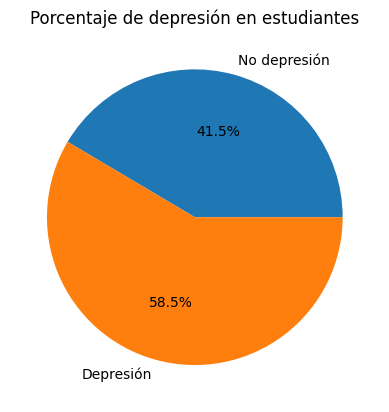

In [46]:
# Grafico pastel  porcentaje de la muestra que declara depresion.
gender_counts = csvFile_copia.groupby('Depression')['id'].count()
gender_percentage = (gender_counts / gender_counts.sum()) * 100

# Diccionario de mapeo (0: No depresión, 1: Depresión)
label_map = {0: 'No depresión', 1: 'Depresión'}

# Aplicar el mapeo a las etiquetas
custom_labels = [label_map[key] for key in gender_percentage.index]


plt.title("Porcentaje de depresión en estudiantes")
plt.pie(gender_percentage, labels=custom_labels, autopct='%.1f%%')
plt.show()

Se observa que de los estudiantes que completaron la encuesta existe una proporción mayor de aquellos que declaran tener depresión, en un 58,5% contra un 41,5% que declara no tener depresión.

**Distribución de Edad en estudiantes**

---



In [47]:

# Distribución Edad

# Datos de muestra

var = csvFile_copia["Age"]
fig = px.violin(y = var)
# Título del gráfico
fig.update_layout(title="Distribución de edad")
fig.show()

Se observa que las edades se concentran en edades jóvenes, al rededor de los 20 años hasta los 35, y luego hay algunos casos puntuales con edades mayores.

**Resultados académicos**

---



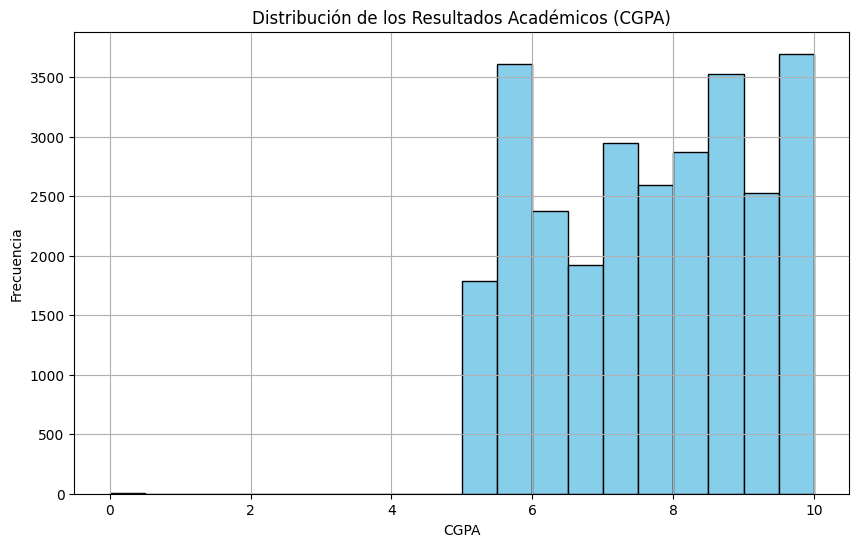

In [48]:
## Hago un histograma para entender como se distribuye la variable de resultados academicos


# Crear histograma para la variable 'CGPA'
plt.figure(figsize=(10,6))
plt.hist(csvFile_copia['CGPA'], bins=20, color='skyblue', edgecolor='black')  # Ajusta el número de bins si lo necesitas

# Personalizar el gráfico
plt.title('Distribución de los Resultados Académicos (CGPA)')
plt.xlabel('CGPA')
plt.ylabel('Frecuencia')
plt.grid(True)

# Mostrar el gráfico
plt.show()

Se observa que las notas se concentran en la segunda mitad de la escala de notas, es decir entre los valores 5 y 10.

In [49]:
## Cual es el minimo CGPA de la poblacion sin ser 0?

CGPAsincero = csvFile_copia[csvFile_copia['CGPA'] > 0]

CGPAsincero.describe()

## 5.03

,id,Age,Academic Pressure,CGPA,Study Satisfaction,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
count,27861.000000,27861.000000,27861.000000,27861.000000,27861.000000,27861.000000,27861.000000,27858.000000,27861.000000,27861.000000
mean,70434.708912,25.821112,3.141309,7.658501,2.944187,0.632605,7.157819,3.139350,0.483938,0.585191
std,40633.834254,4.905754,1.380989,1.464620,1.360559,0.482104,3.706947,1.437365,0.499751,0.492698
min,2.000000,18.000000,0.000000,5.030000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,35046.000000,21.000000,2.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000,0.000000
50%,70650.000000,25.000000,3.000000,7.770000,3.000000,1.000000,8.000000,3.000000,0.000000,1.000000
75%,105810.000000,30.000000,4.000000,8.920000,4.000000,1.000000,10.000000,4.000000,1.000000,1.000000
max,140699.000000,59.000000,5.000000,10.000000,5.000000,1.000000,12.000000,5.000000,1.000000,1.000000


In [50]:
## Cuantos 0 hay?

ceros = len(csvFile_copia[csvFile_copia['CGPA'] == 0])

ceros

## Hay solo 9 valores con 0, parece ser que 0 es un NaN

9

In [51]:
## Reemplazo los 0 por la media

# Calcular la media de la columna 'CGPA', ignorando los valores 0
media_CGPA = csvFile_copia[csvFile_copia['CGPA'] != 0]['CGPA'].mean()

# Reemplazar los valores 0 por la media
csvFile_copia['CGPA'] = csvFile_copia['CGPA'].replace(0, media_CGPA)

**Distribución de Género**


---



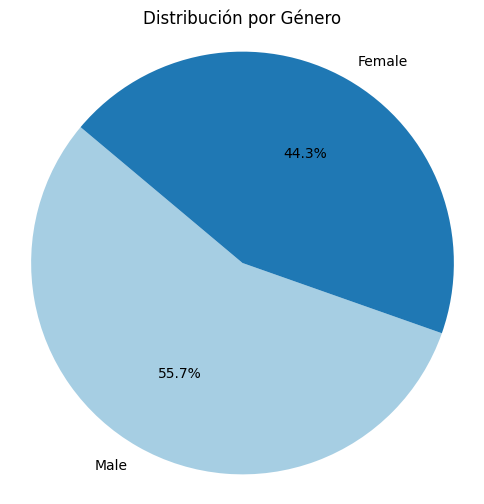

In [52]:


# Contar
genero_counts = csvFile_copia['Gender'].value_counts()

# Gráfico
plt.figure(figsize=(6, 6))
plt.pie(
    genero_counts,
    labels=genero_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired.colors
)

plt.title('Distribución por Género')
plt.axis('equal')  # mantiene el círculo redondo
plt.show()



Se observa que hay un porcentaje ligeramente mayor de hombres al respecto de las mujeres en el total de estudiantes encuestados.

**Porcentaje de pensamientos suicidas**


---



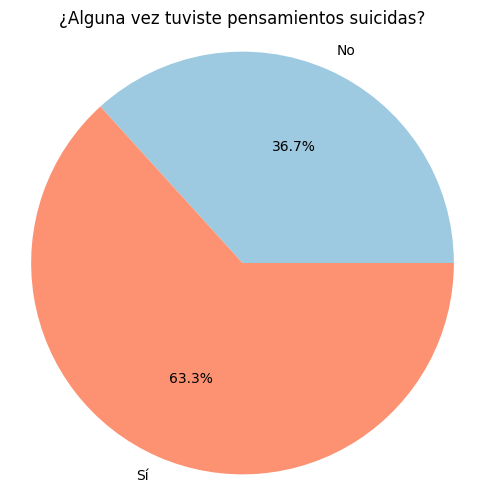

In [53]:

# Renombrar columna para evitar problemas con espacios y símbolos
df = csvFile_copia.rename(columns={'Have you ever had suicidal thoughts ?': 'Suicidal_Thoughts'})

# Conteo de respuestas
conteo_suicidio = df['Suicidal_Thoughts'].value_counts().sort_index()

# Mapear 0/1 a etiquetas comprensibles
etiquetas = ['No', 'Sí']

# Gráfico de torta
conteo_suicidio.plot(
    kind='pie',
    labels=etiquetas,
    autopct='%1.1f%%',
    figsize=(6, 6),
    title='¿Alguna vez tuviste pensamientos suicidas?',
    ylabel='',  # Oculta la etiqueta del eje Y
    colors=['#9ecae1', '#fc9272']
)

plt.axis('equal')
plt.show()


Se observa que la mayoría de los estudiantes encuestados ha tenido pensamientos suicidas, alcanzando a más del 60% del total.

**Análisis de normalidad**

**Analizamos si edad se distribuye de manera normal**

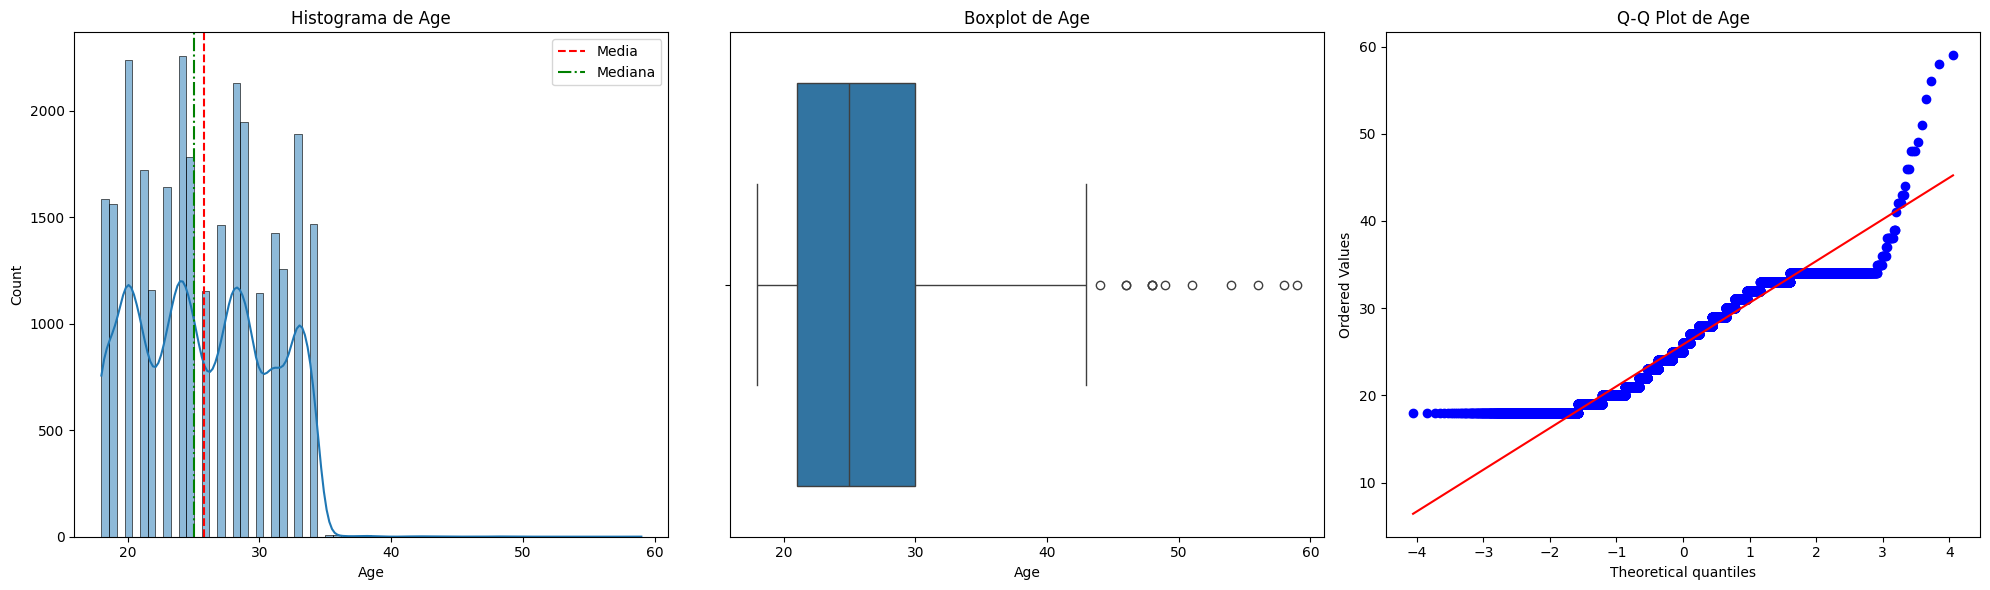


Estadísticas resumidas para Age:
count    27870.000000
mean        25.821134
std          4.906574
min         18.000000
25%         21.000000
50%         25.000000
75%         30.000000
max         59.000000
Name: Age, dtype: float64

Asimetría: 0.1325
Curtosis: -0.8463

Prueba de normalidad Shapiro-Wilk:
Estadístico: 0.9502, p-valor: 1.2578e-68
Los datos no siguen una distribución normal (rechaza H0)


In [54]:
## visualizacion normal Edad estudiantes

def visualizar_distribucion(datos, columna):
    """Visualiza la distribución de una variable con histograma, boxplot y QQ plot."""
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Histograma con curva de densidad
    sns.histplot(datos[columna], kde=True, ax=axes[0])
    axes[0].axvline(datos[columna].mean(), color='red', linestyle='--', label='Media')
    axes[0].axvline(datos[columna].median(), color='green', linestyle='-.', label='Mediana')
    axes[0].set_title(f'Histograma de {columna}')
    axes[0].legend()

    # Boxplot
    sns.boxplot(x=datos[columna], ax=axes[1])
    axes[1].set_title(f'Boxplot de {columna}')

    # QQ plot
    stats.probplot(datos[columna], plot=axes[2])
    axes[2].set_title(f'Q-Q Plot de {columna}')

    plt.tight_layout()
    plt.show()

    # Mostrar estadísticas resumidas
    print(f"\nEstadísticas resumidas para {columna}:")
    print(datos[columna].describe())

    # Mostrar medidas de forma
    print(f"\nAsimetría: {datos[columna].skew():.4f}")
    print(f"Curtosis: {datos[columna].kurtosis():.4f}")

    # Prueba de normalidad
    stat, p_valor = stats.shapiro(datos[columna])
    print(f"\nPrueba de normalidad Shapiro-Wilk:")
    print(f"Estadístico: {stat:.4f}, p-valor: {p_valor:.4e}")
    if p_valor < 0.05:
        print("Los datos no siguen una distribución normal (rechaza H0)")
    else:
        print("No hay evidencia para rechazar la normalidad de los datos")

# Ejemplo de uso para cada columna
# for columna in df.columns:
visualizar_distribucion(csvFile_copia, 'Age')

**Analizamos si las notas se distribuyen normalmente**


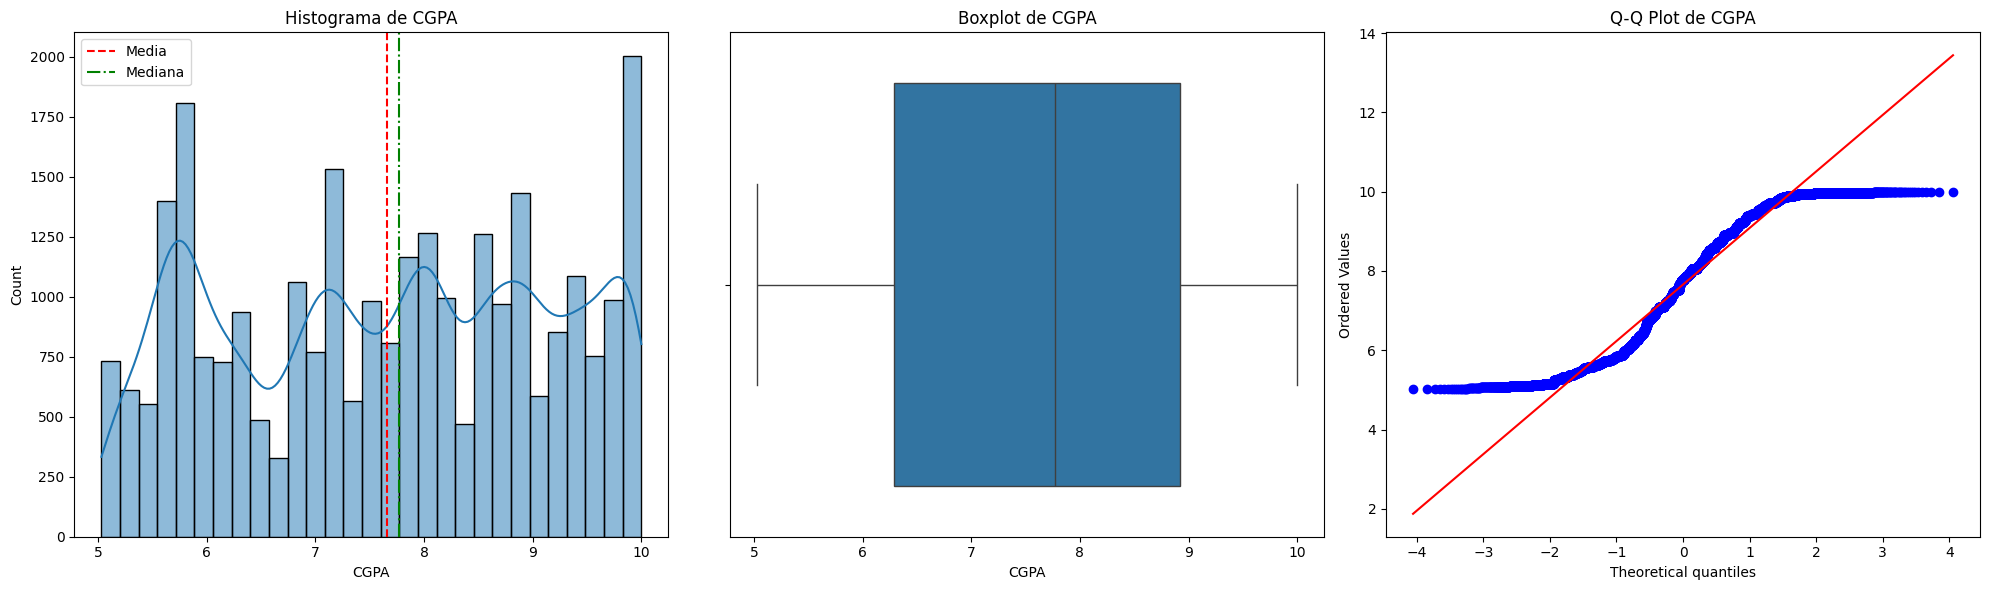


Estadísticas resumidas para CGPA:
count    27870.000000
mean         7.658501
std          1.464384
min          5.030000
25%          6.290000
50%          7.770000
75%          8.920000
max         10.000000
Name: CGPA, dtype: float64

Asimetría: -0.0736
Curtosis: -1.2288

Prueba de normalidad Shapiro-Wilk:
Estadístico: 0.9477, p-valor: 1.1370e-69
Los datos no siguen una distribución normal (rechaza H0)


In [55]:
visualizar_distribucion(csvFile_copia, 'CGPA')

** Múltiples test de normalidad para las variables numéricas **


---




In [56]:
# Función para aplicar múltiples tests de normalidad
def test_normalidad(datos, nombre=None):
    """
    Aplica múltiples tests de normalidad a un conjunto de datos
    y devuelve los resultados en un DataFrame.
    """
    # Shapiro-Wilk test
    shapiro_test = stats.shapiro(datos)

    # Anderson-Darling test
    anderson_test = stats.anderson(datos, dist='norm')

    # Kolmogorov-Smirnov test
    ks_test = stats.kstest(datos, 'norm', args=(datos.mean(), datos.std()))

    # Crear DataFrame con resultados
    resultados = pd.DataFrame({
        'Test': ['Shapiro-Wilk', 'Kolmogorov-Smirnov'],
        'Estadístico': [shapiro_test[0], ks_test[0]],
        'p-valor': [shapiro_test[1], ks_test[1]],
        'Normalidad (α=0.05)': [
            'Aceptada' if shapiro_test[1] > 0.05 else 'Rechazada',
            'Aceptada' if ks_test[1] > 0.05 else 'Rechazada'
        ]
    })

    # Añadir resultados de Anderson-Darling
    # (este test tiene múltiples valores críticos)
    ad_result = 'Rechazada'
    for i, nivel in enumerate([15, 10, 5, 2.5, 1]):
        if anderson_test[0] < anderson_test[1][i]:
            ad_result = f'Aceptada (α={nivel}%)'
            break

    ad_row = pd.DataFrame({
        'Test': ['Anderson-Darling'],
        'Estadístico': [anderson_test[0]],
        'p-valor': [None],  # Anderson-Darling no reporta p-valor directamente
        'Normalidad (α=0.05)': [ad_result]
    })

    resultados = pd.concat([resultados, ad_row], ignore_index=True)

    if nombre:
        print(f"Resultados para: {nombre}")

    return resultados

# Aplicar los tests a cada conjunto de datos
resultados = {}
#for columna in df.columns:
resultados['Age'] = test_normalidad(csvFile_copia['Age'], 'Age')
print(resultados['Age'])
print("\n" + "="*80 + "\n")

Resultados para: Age
                 Test  Estadístico        p-valor Normalidad (α=0.05)
0        Shapiro-Wilk     0.950238   1.257777e-68           Rechazada
1  Kolmogorov-Smirnov     0.092100  3.539512e-206           Rechazada
2    Anderson-Darling   351.053518            NaN           Rechazada




In [57]:
# tests de normalidad para Notas CGPA

# Aplicar los tests a cada conjunto de datos
resultados = {}
#for columna in df.columns:
resultados['CGPA'] = test_normalidad(csvFile_copia['CGPA'], 'CGPA')
print(resultados['CGPA'])
print("\n" + "="*80 + "\n")

Resultados para: CGPA
                 Test  Estadístico        p-valor Normalidad (α=0.05)
0        Shapiro-Wilk     0.947697   1.136957e-69           Rechazada
1  Kolmogorov-Smirnov     0.076598  1.158145e-142           Rechazada
2    Anderson-Darling   375.038904            NaN           Rechazada




Se observa que tanto la edad como las notas no siguen una distribución normal en el conjunto de datos.

## **Análisis bivariado y multivariado**

El análisis bivariado busca estudiar la relación entre dos variables, mientras que el multivariado extiende esta exploración a múltiples variables de forma simultánea. Las técnicas más comunes incluyen:

* Tablas de contingencia y gráficos de barras apiladas para variables categóricas.
* Diagramas de dispersión (scatter plots) para relaciones entre variables numéricas.
* Mapas de calor (heatmaps) con coeficientes de correlación (como Pearson o Spearman) para estudiar asociaciones lineales.
* Gráficos de violín, swarm o boxplots múltiples para comparar distribuciones condicionadas a otra variable.
* Análisis de varianza y covarianza, coeficientes de correlación: Pearson, Spearman.
* Prueba de independencia de Chi-Cuadrado y coeficiente de V de Cramer.


**Género y depresión**


---



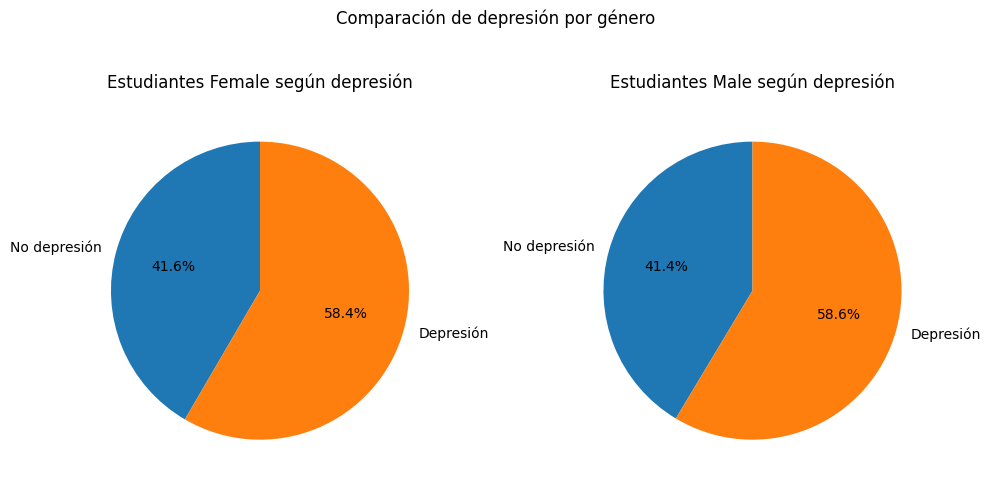

In [58]:

# Filtrar y agrupar por género y depresión
grouped = csvFile_copia.groupby(['Gender', 'Depression'])['id'].count().unstack(fill_value=0)

# Calcular porcentajes
percentages = grouped.div(grouped.sum(axis=1), axis=0) * 100

# Mapeo de etiquetas
label_map = {0: 'No depresión', 1: 'Depresión'}

# Crear figura con dos subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, gender in zip(axes, ['Female', 'Male']):
    # Datos y etiquetas para cada género
    vals = percentages.loc[gender]
    labels = [label_map[k] for k in vals.index]

    # Pintar pie chart en el eje correspondiente
    ax.pie(vals, labels=labels, autopct='%.1f%%', startangle=90)
    ax.set_title(f"Estudiantes {gender} según depresión")
    ax.axis('equal')  # Para que los círculos salgan redondos

plt.suptitle("Comparación de depresión por género")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Cuando profundizamos el análisis de depresión de acuerdo al género, observamos que para el caso de las mujeres y los hombres, la proporción de depresión es muy similar a la del total, declarando un 58% de presencia de depresión contra un 41% de no depresión para ambos géneros.


**Región y Depresión**


---



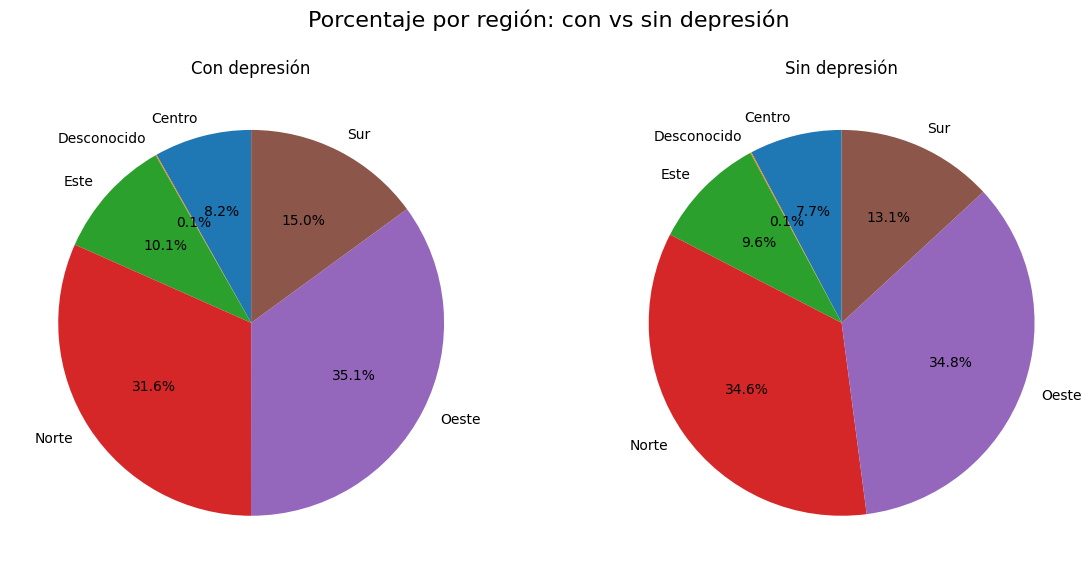

In [59]:

# Filtramos las dos categorías
solo_depression = csvFile_copia[csvFile_copia['Depression'] == 1]
solo_no_depression = csvFile_copia[csvFile_copia['Depression'] == 0]

# Contamos por región
count_dep = solo_depression.groupby('Region')['id'].count()
count_no_dep = solo_no_depression.groupby('Region')['id'].count()

# Pasamos a porcentajes
pct_dep = (count_dep / count_dep.sum()) * 100
pct_no_dep = (count_no_dep / count_no_dep.sum()) * 100

# Creamos la figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Pie de depresión
axes[0].pie(pct_dep, labels=pct_dep.index, autopct='%.1f%%', startangle=90)
axes[0].set_title("Con depresión")

# Pie de no depresión
axes[1].pie(pct_no_dep, labels=pct_no_dep.index, autopct='%.1f%%', startangle=90)
axes[1].set_title("Sin depresión")

# Título general
fig.suptitle("Porcentaje por región: con vs sin depresión", fontsize=16)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Se observa que las proporciones de estudiantes con y sin depresión se distribuyen de manera bastante similar, concentrándose en las zonas Norte y Oeste.

**Notas (CGPA) y Depresión**

---



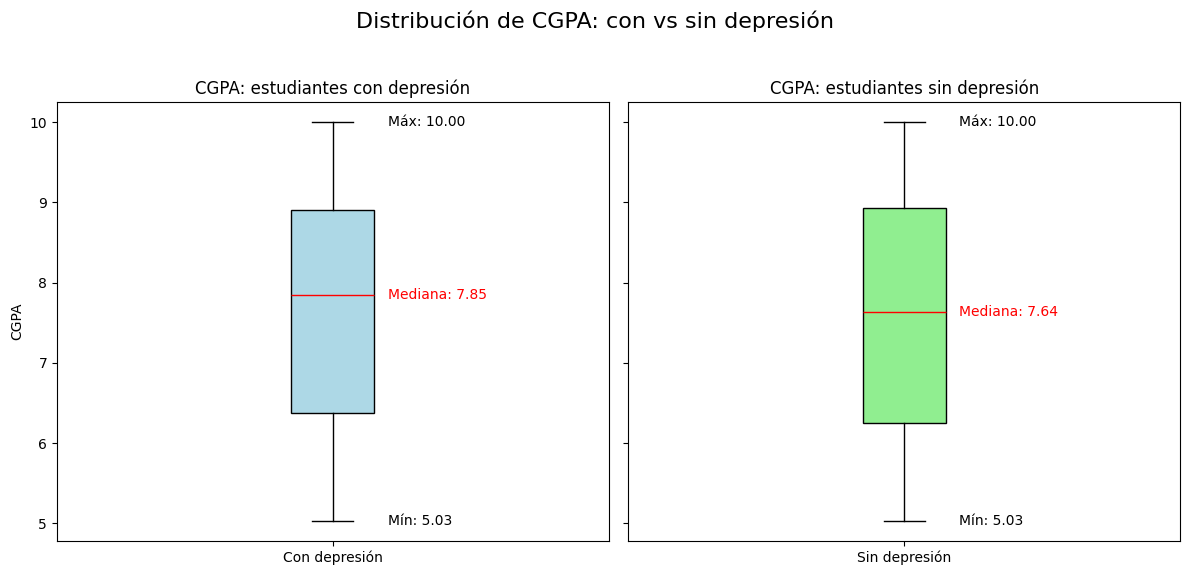

In [60]:

# Filtrar datos
dep = csvFile_copia[csvFile_copia['Depression'] == 1]["CGPA"]
no_dep = csvFile_copia[csvFile_copia['Depression'] == 0]["CGPA"]

# Preparamos la figura con dos subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Boxplot para con depresión
axes[0].boxplot(dep, patch_artist=True,
                boxprops=dict(facecolor="lightblue"),
                medianprops=dict(color="red"))
axes[0].set_title("CGPA: estudiantes con depresión")
axes[0].set_xticks([1])
axes[0].set_xticklabels(["Con depresión"])
axes[0].set_ylabel("CGPA")

# Calcular valores clave y anotarlos
min_val, max_val, med_val = dep.min(), dep.max(), np.median(dep)
axes[0].text(1.1, min_val, f"Mín: {min_val:.2f}", va='center')
axes[0].text(1.1, max_val, f"Máx: {max_val:.2f}", va='center')
axes[0].text(1.1, med_val, f"Mediana: {med_val:.2f}", va='center', color='red')

# Boxplot para sin depresión
axes[1].boxplot(no_dep, patch_artist=True,
                boxprops=dict(facecolor="lightgreen"),
                medianprops=dict(color="red"))
axes[1].set_title("CGPA: estudiantes sin depresión")
axes[1].set_xticks([1])
axes[1].set_xticklabels(["Sin depresión"])

# Calcular valores clave y anotarlos
min_val2, max_val2, med_val2 = no_dep.min(), no_dep.max(), np.median(no_dep)
axes[1].text(1.1, min_val2, f"Mín: {min_val2:.2f}", va='center')
axes[1].text(1.1, max_val2, f"Máx: {max_val2:.2f}", va='center')
axes[1].text(1.1, med_val2, f"Mediana: {med_val2:.2f}", va='center', color='red')

# Título general y ajuste
fig.suptitle("Distribución de CGPA: con vs sin depresión", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Se observa que en lo que respecta a las notas de los estudiantes, no se evidencian grandes diferencias entre estudiantes que presentan depresión (con media 7.85) y estudiantes sin depresión (con media 7.64). En general, las notas se concentran en los valores superiores de la escala de notas para todos los estudiantes encuestados, tomando en cuenta que el rango de notas posibles va desde 0 hasta 10.



**Proporción de depresión por resultados académicos**


---



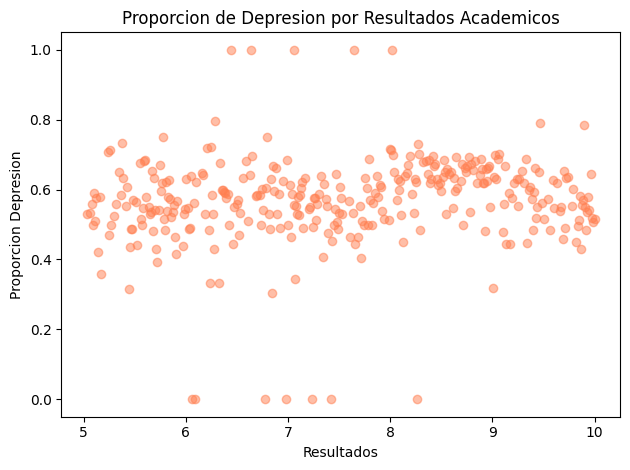

In [61]:
## Grafico los resultados academicos

# Creo variable

resultados_academicos = csvFile_copia.groupby('CGPA')['Depression'].mean()


# Grafico

plt.scatter(resultados_academicos.index,resultados_academicos.values, alpha=0.5, color = 'coral')

# Titulos

plt.title('Proporcion de Depresion por Resultados Academicos')
plt.xlabel('Resultados')
plt.ylabel('Proporcion Depresion')

# Ajustar el gráfico de forma que sea más fácil de leer
plt.tight_layout()

# Agregar números arriba de cada barra
#for i, valor in enumerate(resultados_academicos.values):
#    plt.text(resultados_academicos.index[i], valor + 0.01, f'{valor:.2f}', ha='center')

# Print

plt.show()

Dentro del rango total de calificaciones de la muestra, se ve que la mayoría de los registros se ubican en una banda que va del 0.4 al 0.8 de probabilidad de depresión.

**Horas de sueño para estudiantes con y sin depresión**

---



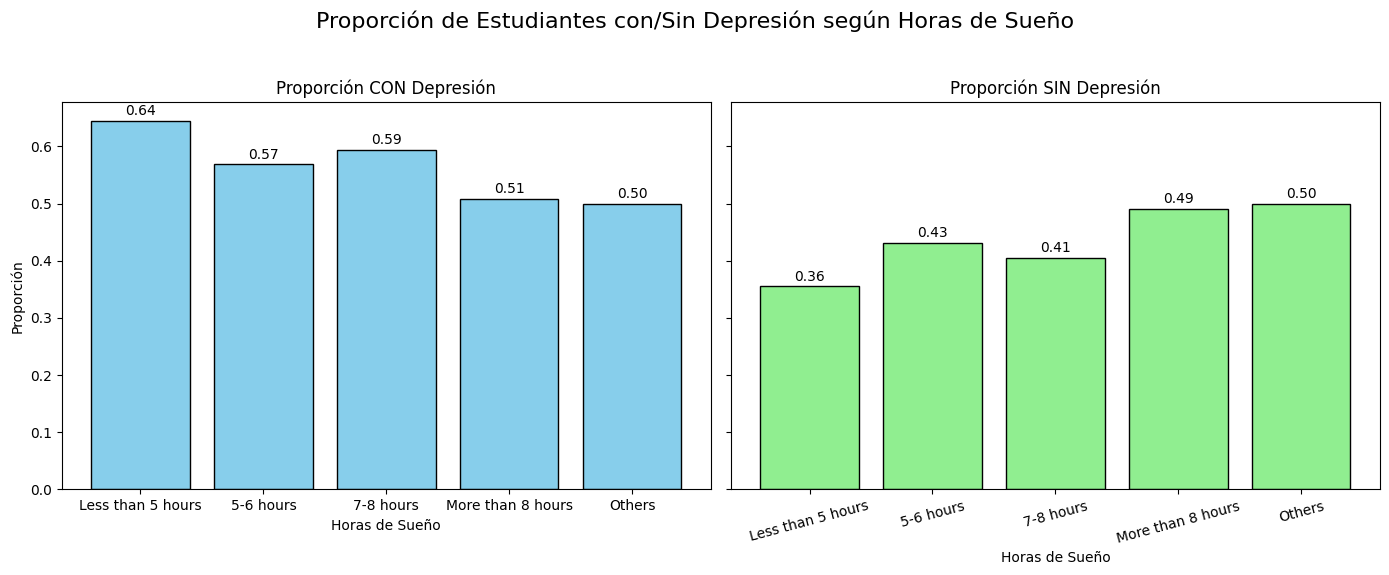

In [62]:

# Definir orden y convertir a categoría ordenada
orden = ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours', 'Others']
csvFile_copia['Sleep Duration'] = pd.Categorical(
    csvFile_copia['Sleep Duration'],
    categories=orden,
    ordered=True
)

# Calcular proporciones
prop_dep = csvFile_copia.groupby('Sleep Duration')['Depression'].mean()
prop_no_dep = 1 - prop_dep  # equivalente a mean(Depression==0)

# Crear figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Gráfico para con depresión
axes[0].bar(prop_dep.index, prop_dep.values, color='skyblue', edgecolor='black')
axes[0].set_title('Proporción CON Depresión')
axes[0].set_xlabel('Horas de Sueño')
axes[0].set_ylabel('Proporción')
for i, v in enumerate(prop_dep.values):
    axes[0].text(i, v + 0.01, f'{v:.2f}', ha='center')

# Gráfico para sin depresión
axes[1].bar(prop_no_dep.index, prop_no_dep.values, color='lightgreen', edgecolor='black')
axes[1].set_title('Proporción SIN Depresión')
axes[1].set_xlabel('Horas de Sueño')
for i, v in enumerate(prop_no_dep.values):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center')

# Título general y ajuste
fig.suptitle('Proporción de Estudiantes con/Sin Depresión según Horas de Sueño', fontsize=16)
plt.xticks(rotation=15)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Se puede ver una relacion negativa entre la cantidad de horas que duermen los estudiantes y la probabilidad de que tengan depresion. Es decir, entre los estudiantes que presentan depresión se observan patrones de sueño menos saludables, con menos horas de sueño diarias, mientras que para aquellos de no presentan depresión se observan patrones de sueño más saludables, con mas horas de sueño diarias.

**Hábitos alimenticios para estudiantes con y sin depresión**

---



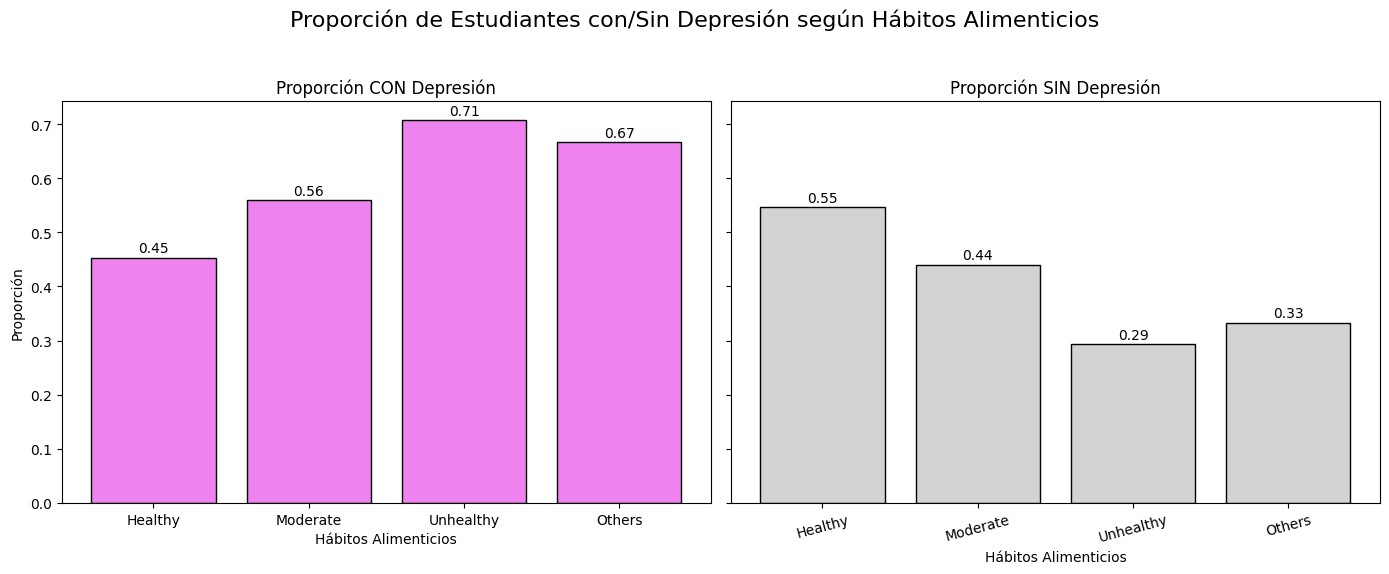

In [63]:


# Definir orden y convertir a categoría ordenada
orden = ['Healthy', 'Moderate', 'Unhealthy', 'Others']
csvFile_copia['Dietary Habits'] = pd.Categorical(
    csvFile_copia['Dietary Habits'],
    categories=orden,
    ordered=True
)

# Calcular proporciones
prop_dep = csvFile_copia.groupby('Dietary Habits')['Depression'].mean()
prop_no_dep = 1 - prop_dep  # proporción sin depresión

# Crear figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Gráfico para proporción CON depresión
axes[0].bar(prop_dep.index, prop_dep.values,
            color='violet', edgecolor='black')
axes[0].set_title('Proporción CON Depresión')
axes[0].set_xlabel('Hábitos Alimenticios')
axes[0].set_ylabel('Proporción')
for i, v in enumerate(prop_dep.values):
    axes[0].text(i, v + 0.01, f'{v:.2f}', ha='center')

# Gráfico para proporción SIN depresión
axes[1].bar(prop_no_dep.index, prop_no_dep.values,
            color='lightgray', edgecolor='black')
axes[1].set_title('Proporción SIN Depresión')
axes[1].set_xlabel('Hábitos Alimenticios')
for i, v in enumerate(prop_no_dep.values):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center')

# Título general y ajuste de layout
fig.suptitle('Proporción de Estudiantes con/Sin Depresión según Hábitos Alimenticios', fontsize=16)
plt.xticks(rotation=15)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Al igual que con los hábitos alimentcios, se observa que para los estudiantes con depresión existe una mayor proporción de hábitos no saludables, mientras que esta proporción se invierte para estudiantes que no presentan depresión.

**Horas de estudio y depresión**

---



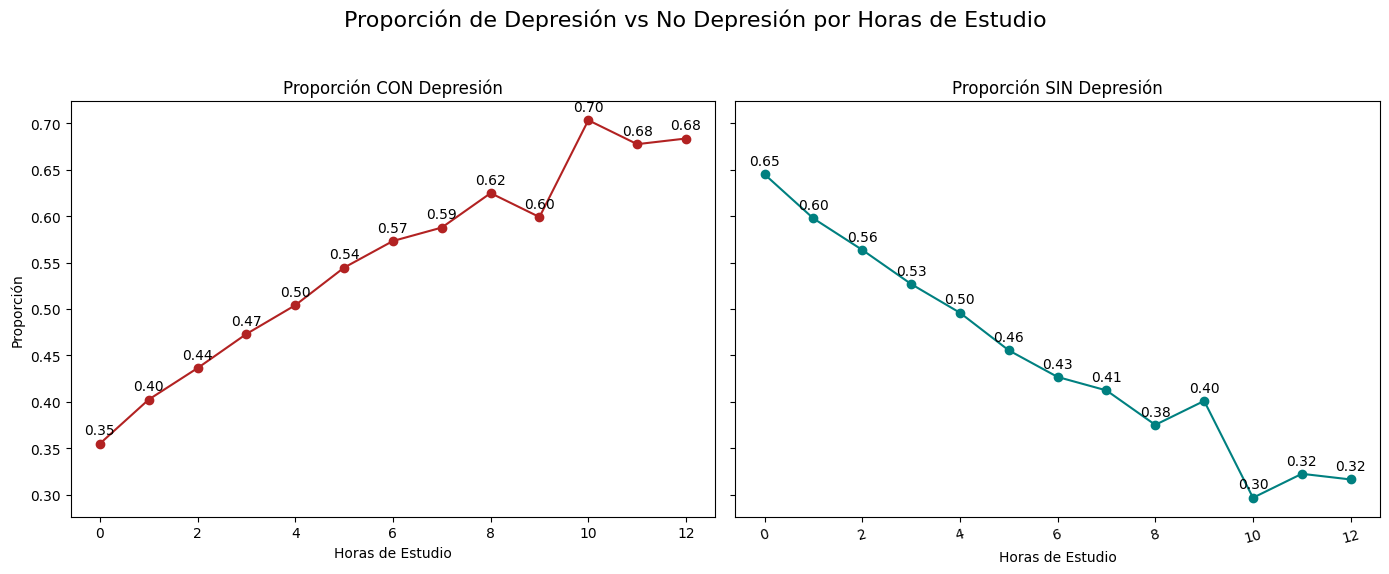

In [64]:

# Calculamos la proporción con y sin depresión por horas de estudio
prop_dep = csvFile_copia.groupby('Study Hours')['Depression'].mean()
prop_no_dep = 1 - prop_dep

# Creamos la figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Gráfico para proporción CON depresión
axes[0].plot(prop_dep.index, prop_dep.values, marker='o', color='firebrick')
axes[0].set_title('Proporción CON Depresión')
axes[0].set_xlabel('Horas de Estudio')
axes[0].set_ylabel('Proporción')
for i, v in enumerate(prop_dep.values):
    axes[0].text(prop_dep.index[i], v + 0.01, f'{v:.2f}', ha='center')

# Gráfico para proporción SIN depresión
axes[1].plot(prop_no_dep.index, prop_no_dep.values, marker='o', color='teal')
axes[1].set_title('Proporción SIN Depresión')
axes[1].set_xlabel('Horas de Estudio')
for i, v in enumerate(prop_no_dep.values):
    axes[1].text(prop_no_dep.index[i], v + 0.01, f'{v:.2f}', ha='center')

# Título común y ajuste de layout
fig.suptitle('Proporción de Depresión vs No Depresión por Horas de Estudio', fontsize=16)
plt.xticks(rotation=15)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Se observa una relación marcada entre horas de estudio y depresión. La proporción de estudiantes con depresión es casi directamente proporcional a la cantidad de horas por estudio diarias del estudiante.

**Gráfico de violín: Edad por depresión**

---



In [65]:
# Datos de muestra
var = csvFile_copia["Age"]
grupo = csvFile_copia["Depression"]

# Crear DataFrame
df = pd.DataFrame({'Edad': var,
                   'Indicador Depresión': grupo})

# Mapear los valores del grupo para que sean más descriptivos
df['Indicador Depresión'] = df['Indicador Depresión'].map({0: 'Sin depresión', 1: 'Con depresión'})

# Crear el gráfico de violín
fig = px.violin(df,
                y='Edad',
                color='Indicador Depresión',
                color_discrete_map={'Sin depresión': 'blue', 'Con depresión': 'red'},
                title='Distribución de la edad según indicador de depresión')

# Personalizar el diseño
fig.update_layout(
    yaxis_title='Edad',
    xaxis_title='Indicador de Depresión',
    legend_title='Grupo'
)

fig.show()

Se observa que los estudiantes con depresión se concentran en las edades más jóvenes, y van bajando a medida que aumenta la edad. Lo contrario sucede para los estudiantes sin depresión, dando cuenta de que la edad puede ser un factor de importancia para detectar población más vulnerable a esta enfermedad.

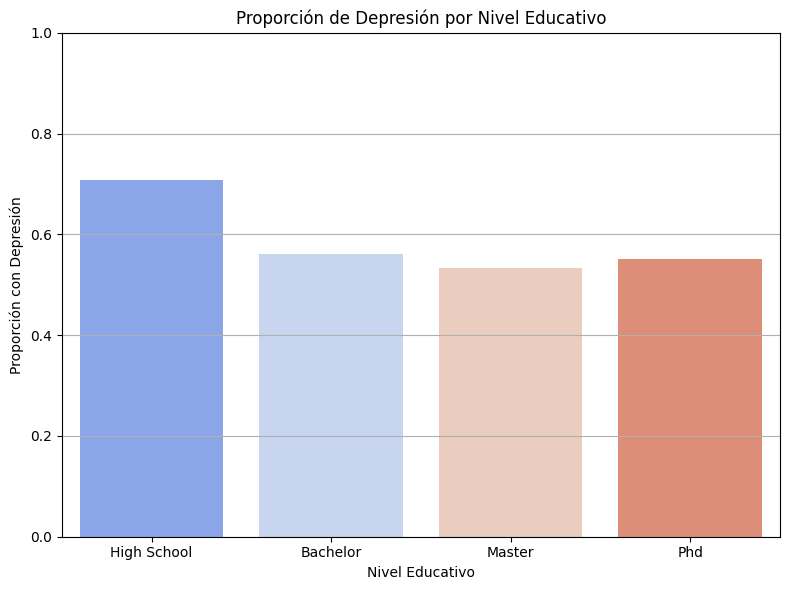

In [66]:


# Limpiar y estandarizar Degree_level
csvFile_copia['Degree_level'] = csvFile_copia['Degree_level'].str.strip().str.title()

# Orden deseado
orden_educativo = ['High School', 'Bachelor', 'Master', 'Phd']

# Gráfico
plt.figure(figsize=(8, 6))
sns.barplot(
    data=csvFile_copia,
    x='Degree_level',
    y='Depression',
    estimator='mean',
    errorbar=None,
    order=orden_educativo,
    palette='coolwarm'
)

# Estética
plt.title('Proporción de Depresión por Nivel Educativo')
plt.xlabel('Nivel Educativo')
plt.ylabel('Proporción con Depresión')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()




Se observa un mayor porcentaje de depresión en Secundaria, que baja a medida que aumenta el nivel educativo, mientras que para Doctorado la proporción asciende levemente al respecto de Maestría.

**Presión académica y nivel de estudio**


---



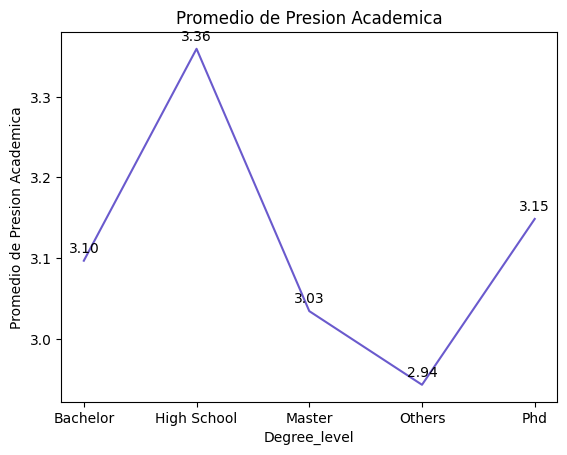

In [67]:
## Promedio de Presion Academica por Degree

# Creo variable

satsfaccion_estudio = csvFile_copia.groupby('Degree_level')['Academic Pressure'].mean()

# Grafico

plt.plot(satsfaccion_estudio.index,satsfaccion_estudio.values, color = 'slateblue')

# Titulos

plt.title('Promedio de Presion Academica')
plt.xlabel('Degree_level')
plt.ylabel('Promedio de Presion Academica')

# Agregar números arriba de cada barra
for i, valor in enumerate(satsfaccion_estudio.values):
    plt.text(satsfaccion_estudio.index[i], valor + 0.01, f'{valor:.2f}', ha='center')

# Print

plt.show()

Se observa que la categoría Otros trae ruido a la variable de nivel educativo, por lo que una alternativa será eliminarla del gráfico.

In [68]:
#Verifico los valores que existen en el df para filtrar correctamente
print("Cantidad total de filas:", len(csvFile_copia))
print("Valores únicos en 'Degree_level':", csvFile_copia['Degree_level'].unique())
print("Valores únicos en 'Depression':", csvFile_copia['Depression'].unique())

df_filtrado = csvFile_copia[
    (csvFile_copia['Degree_level'] != 'Others') &
    (csvFile_copia['Depression'] == 'Yes')
]
print("Filas con Depression=='Yes' y Degree_level!='Others':", len(df_filtrado))
print(df_filtrado[['Degree_level', 'Depression', 'Academic Pressure']].head())


Cantidad total de filas: 27870
Valores únicos en 'Degree_level': ['Bachelor' 'Master' 'Phd' 'High School' 'Others']
Valores únicos en 'Depression': [1 0]
Filas con Depression=='Yes' y Degree_level!='Others': 0
Empty DataFrame
Columns: [Degree_level, Depression, Academic Pressure]
Index: []


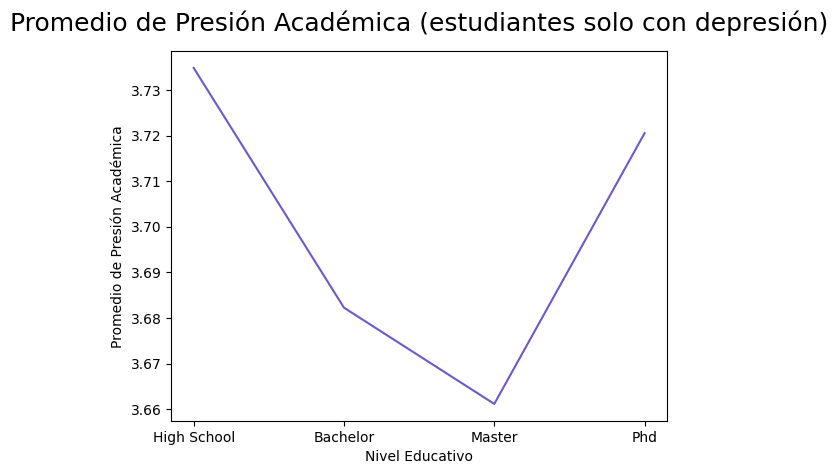

In [69]:
#  Definir orden deseado
orden_niveles = ['High School', 'Bachelor', 'Master', 'Phd']

# y convierto la coluna en una categoria ordenada
csvFile_copia['Degree_level'] = pd.Categorical(csvFile_copia['Degree_level'], categories=orden_niveles, ordered=True)

# 1. Filtrar para excluir "Others"
df_filtrado = csvFile_copia[
    (csvFile_copia['Degree_level'] != 'Others') &
    (csvFile_copia['Depression'] == 1)
]

# 2. Calcular promedio de Academic Pressure por nivel
satisfaccion_estudio = df_filtrado.groupby('Degree_level')['Academic Pressure'].mean()

# 3. Reindexar para asegurar el orden deseado
orden_niveles = ['High School', 'Bachelor', 'Master', 'Phd']
satisfaccion_estudio = satisfaccion_estudio.reindex(orden_niveles)


# 3. Graficar
plt.plot(satisfaccion_estudio.index, satisfaccion_estudio.values, color='slateblue')
plt.title('Promedio de Presión Académica (estudiantes solo con depresión)', fontsize=18, pad=15)
plt.xlabel('Nivel Educativo')
plt.ylabel('Promedio de Presión Académica')

# Obtén las posiciones en x de los ticks
ticks = plt.gca().get_xticks()



# # Colocar todas las etiquetas sobre cada punto
# for x, valor in zip(xs, satisfaccion_estudio.values):
#     if not np.isnan(valor):
#         plt.text(
#             x,
#             valor + 0.02,
#             f'{valor:.2f}',
#             ha='center',
#             va='bottom',
#             fontsize=12,
#             clip_on=True
#         )

plt.show()

Se observa que  la presión académica es más alta en los niveles educativos menores, y desciende a medida que aumenta el nivel educativo, hasta alcanzar maestría. Posteriormente sube para el Doctorado.

**Pensamientos suicidas y depresión**


---



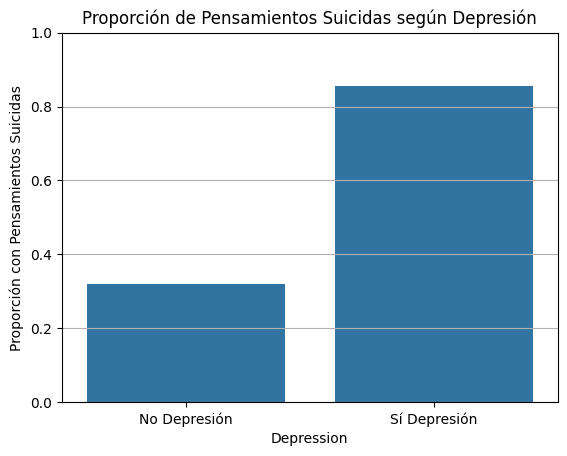

In [70]:


# Renombrar columna para trabajar más fácil
df = csvFile_copia.rename(columns={'Have you ever had suicidal thoughts ?': 'Suicidal'})

# Agrupar y calcular proporción de suicidal thoughts por grupo de depresión
df_grouped = df.groupby('Depression')['Suicidal'].mean().reset_index()
df_grouped['Depression'] = df_grouped['Depression'].map({0: 'No Depresión', 1: 'Sí Depresión'})

# Graficar
sns.barplot(data=df_grouped, x='Depression', y='Suicidal')
plt.title('Proporción de Pensamientos Suicidas según Depresión')
plt.ylabel('Proporción con Pensamientos Suicidas')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()


Se observa que el porcentaje de estudiantes que han tenido pensamientos suicidas es mayor entre aquellos que tienen depresión, si bien aquellos que no tienen depresión también declaran un porcentaje de pensamientos suicidas.

**Mapa de calor: Proporción de depresión en Horas de estudio y nivel educativo**

---



In [71]:


# Create a pivot table/crosstab
heatmap_data = pd.crosstab(csvFile_copia['Degree_level'], csvFile_copia['Study Hours'], values=csvFile_copia['Depression'], aggfunc='mean') # You can use 'count' or other aggregation functions if needed

# Plot the heatmap
fig = px.imshow(heatmap_data,
                labels=dict(x="Study Hours", y="Degree", color="Proportion of Depression"), # Adjust the color label
                x=heatmap_data.columns, # Use the columns from the pivot table
                y=heatmap_data.index    # Use the index from the pivot table
               )
fig.update_xaxes(side="top")
fig.show()

#'Degree_level'

Se observa que para los niveles educativos más bajos, Secundaria y Grado, la proporción de depresión aumenta a medida que aumentan las horas de estudio. Para Maestría y Doctorado, si bien también se repite esta tendencia, no es tan marcado el efecto de las horas de estudio.



**Mapa de calor: Nivel de estudio, presión académica y depresión**

---



In [72]:
# pero antes defino el orden manualmente
orden = ['High School', 'Bachelor', 'Master', 'Phd', 'Others']

# y convierto la coluna en una categoria ordenada
csvFile_copia['Degree_level'] = pd.Categorical(csvFile_copia['Degree_level'], categories=orden, ordered=True)

# Create a pivot table/crosstab
heatmap_data = pd.crosstab(csvFile_copia['Degree_level'], csvFile_copia['Academic Pressure'], values=csvFile_copia['Depression'], aggfunc='mean') # You can use 'count' or other aggregation functions if needed

# Plot the heatmap
fig = px.imshow(heatmap_data,
                labels=dict(x='Academic Pressure', y='Degree_level', color="Proportion of Depression"), # Adjust the color label
                x=heatmap_data.columns, # Use the columns from the pivot table
                y=heatmap_data.index    # Use the index from the pivot table
               )
fig.update_xaxes(side="top")
fig.show()

Se observa que a mayor presión académica hay una mayor proporción de depresión en todos los niveles educativos. Sin embargo, para Secundaria se observa una mayor sensibilidad a la presión académica, ya que a menores niveles de presión se observan proporciones mas altas de depresión.

Por lo tanto, se concluye que estrategias de prevención deberían enfocarse en estudiantes de secundaria y pregrado bajo alta presión académica.

**Mapas de calor: Horas de estudio, nivel educativo y depresión**

---



In [73]:


# Create a pivot table/crosstab
heatmap_data = pd.crosstab(csvFile_copia['Degree_level'], csvFile_copia['Study Hours'], values=csvFile_copia['Depression'], aggfunc='mean') # You can use 'count' or other aggregation functions if needed

# Plot the heatmap
fig = px.imshow(heatmap_data,
                labels=dict(x="Study Hours", y="Degree_level", color="Proportion of Depression"), # Adjust the color label
                x=heatmap_data.columns, # Use the columns from the pivot table
                y=heatmap_data.index    # Use the index from the pivot table
               )
fig.update_xaxes(side="top")
fig.show()

#'Degree_level'

In [74]:
import plotly.express as px

# Crear pivot table
heatmap_data = pd.crosstab(
    csvFile_copia['Degree_level'],
    csvFile_copia['Study Hours'],
    values=csvFile_copia['Depression'],
    aggfunc='mean'
)

# Dibujar heatmap
fig = px.imshow(
    heatmap_data,
    labels=dict(x="Study Hours", y="Degree Level", color="Proporción de Depresión"),
    x=heatmap_data.columns,
    y=heatmap_data.index
)

# Mover el eje X arriba
fig.update_xaxes(side="top")

# Ajustar márgenes para evitar cortes
fig.update_layout(
    margin=dict(t=80, l=120, r=80, b=120),
    font=dict(
        family="Arial",
        size=24      # tamaño global de la fuente
    ),
    title_font_size=28,  # si agregas un título
    coloraxis_colorbar=dict(
        title_font=dict(size=24),   # título de la barra de color
        tickfont=dict(size=20)      # valores de la barra de color
    )
)

# Tamaño de los ticks de cada eje
fig.update_xaxes(tickfont=dict(size=22))
fig.update_yaxes(tickfont=dict(size=22))

fig.show()



Si bien se observa que a mayor horas de estudio hay una proporción mayor de depresión, al igual que con presión académica se detaca una mayor sensibilidad en los niveles educativos más bajos a la influencia de esta relación.


**Mapa de calor: Nivel educativo, hábitos alimenticios y depresión**

---



In [75]:

# Create a pivot table/crosstab
heatmap_data = pd.crosstab(csvFile_copia['Dietary Habits'], csvFile_copia['Degree_level'], values=csvFile_copia['Depression'], aggfunc='mean') # You can use 'count' or other aggregation functions if needed

# Plot the heatmap
fig = px.imshow(heatmap_data,
                labels=dict(x='Degree_level', y='Dietary Habits', color="Proportion of Depression"), # Adjust the color label
                x=heatmap_data.columns, # Use the columns from the pivot table
                y=heatmap_data.index    # Use the index from the pivot table
               )
fig.update_xaxes(side="top")
fig.show()

Se obseva que la depresión aumenta ante habitos alimenticios menos saludables. Para Secundaria, este efecto se intensifica, ya que los valores son más altos en todas las categorías a comparación de niveles educativos más altos.

**Mapa de calor: presión académica, hábitos alimenticios y depresión**


---



In [76]:

# Create a pivot table/crosstab
heatmap_data = pd.crosstab(csvFile_copia['Dietary Habits'], csvFile_copia['Academic Pressure'], values=csvFile_copia['Depression'], aggfunc='mean') # You can use 'count' or other aggregation functions if needed

# Plot the heatmap
fig = px.imshow(heatmap_data,
                labels=dict(x='Academic Pressure', y='Dietary Habits', color="Proportion of Depression"), # Adjust the color label
                x=heatmap_data.columns, # Use the columns from the pivot table
                y=heatmap_data.index    # Use the index from the pivot table
               )
fig.update_xaxes(side="top")
fig.show()

#'Degree_level'

Se observa que a mayor presión académica, hay más depresión estudiantil. Sin embargo, los hábitos alimenticios modulan el impacto, reduciendolo para aquellos estudiantes que tengan habitos alimenticios saludables.

**Mapa de calor: Nivel educativo, horas de sueño y depresión**

---



In [77]:
# pero antes defino el orden manualmente
orden = ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours', 'Others']

# y convierto la coluna en una categoria ordenada
csvFile_copia['Sleep Duration'] = pd.Categorical(csvFile_copia['Sleep Duration'], categories=orden, ordered=True)

# Create a pivot table/crosstab
heatmap_data = pd.crosstab(csvFile_copia['Sleep Duration'], csvFile_copia['Degree_level'], values=csvFile_copia['Depression'], aggfunc='mean') # You can use 'count' or other aggregation functions if needed

# Plot the heatmap
fig = px.imshow(heatmap_data,
                labels=dict(x='Degree_level', y='Sleep Duration', color="Proportion of Depression"), # Adjust the color label
                x=heatmap_data.columns, # Use the columns from the pivot table
                y=heatmap_data.index    # Use the index from the pivot table
               )
fig.update_xaxes(side="top")
fig.show()

Se observa que a menor cantidad de horas de sueño hay una mayor proporción de depresión. A medida que aumenta la cantidad e horas de sueño, se observan proporciones de depresión más bajos. Se observa que en Secundaria hay una mayor proporción de depresión, y en los niveles más altos hay menos proprción de depresión entre los estudiantes.

**Mapa de calor: presión académica, duración de sueño y proporción de depresión**

---



In [78]:
# pero antes defino el orden manualmente
orden = ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours', 'Others']

# y convierto la coluna en una categoria ordenada
csvFile_copia['Sleep Duration'] = pd.Categorical(csvFile_copia['Sleep Duration'], categories=orden, ordered=True)

# Create a pivot table/crosstab
heatmap_data = pd.crosstab(csvFile_copia['Sleep Duration'], csvFile_copia['Academic Pressure'], values=csvFile_copia['Depression'], aggfunc='mean') # You can use 'count' or other aggregation functions if needed

# Plot the heatmap
fig = px.imshow(heatmap_data,
                labels=dict(x='Academic Pressure', y='Sleep Duration', color='Depression'), # Adjust the color label
                x=heatmap_data.columns, # Use the columns from the pivot table
                y=heatmap_data.index    # Use the index from the pivot table
               )
fig.update_xaxes(side="top")
fig.show()

Se observa para todos los niveles de sueño que la depresión aumenta de forma consistente a medida que aumenta la presión acedémica. Al mismo tiempo, dormir menos horas es un factor que aumenta la proporción de depresión, ya que se observan mayores proporciones a menor duración del sueño. Sin embargo, para altos niveles de presión académica, la proporción de depresión es pareja en todos los niveles de sueño.

**Análisis de variables categóricas**

In [79]:
# Identificar variables categóricas
cat_vars = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
print(f"Variables categóricas identificadas: {cat_vars}\n")

# También podemos considerar variables numéricas con pocos valores únicos
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    if df[col].nunique() < 10:  # Umbral arbitrario, ajusta según tus datos
        print(f"La variable numérica '{col}' podría tratarse como categórica ({df[col].nunique()} valores únicos)")
        cat_vars.append(col)

print("\n")

# Análisis univariado para cada variable categórica
def analisis_univariado(df, var):
    """Realiza un análisis univariado completo para una variable categórica"""
    print(f"Análisis de la variable: {var}")

    # Valores nulos
    n_missing = df[var].isna().sum()
    pct_missing = 100 * n_missing / len(df)
    print(f"Valores nulos: {n_missing} ({pct_missing:.2f}%)")

    # Distribución de frecuencias
    value_counts = df[var].value_counts()
    print("\nDistribución de frecuencias:")

    # Crear tabla con frecuencias absolutas y relativas
    freq_table = pd.DataFrame({
        'Frecuencia': value_counts,
        'Porcentaje (%)': 100 * value_counts / value_counts.sum()
    })
    print(freq_table)

    # Visualización
    plt.figure(figsize=(14, 10))

    # Gráfico de barras
    plt.subplot(2, 2, 1)
    sns.countplot(data=df, x=var, order=value_counts.index)
    plt.title(f'Frecuencia de {var}')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('')
    plt.ylabel('Frecuencia')

    # Gráfico de barras normalizado
    plt.subplot(2, 2, 2)
    sns.barplot(x=freq_table.index, y='Porcentaje (%)', data=freq_table.reset_index())
    plt.title(f'Distribución porcentual de {var}')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('')
    plt.ylabel('Porcentaje (%)')

    # Gráfico de pastel
    plt.subplot(2, 2, 3)
    plt.pie(freq_table['Frecuencia'], labels=freq_table.index, autopct='%1.1f%%')
    plt.title(f'Proporción de {var}')

    # Estadísticas de resumen (si es ordinal o se puede interpretar numéricamente)
    if df[var].dtype in ['int64', 'float64']:
        plt.subplot(2, 2, 4)
        sns.boxplot(data=df, y=var)
        plt.title(f'Boxplot de {var}')

        # Algunas estadísticas adicionales
        print("\nEstadísticas descriptivas:")
        print(df[var].describe())

    plt.tight_layout()
    plt.show()
    print("\n" + "="*50 + "\n")

Variables categóricas identificadas: ['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Region', 'Degree_level']

La variable numérica 'Academic Pressure' podría tratarse como categórica (6 valores únicos)
La variable numérica 'Study Satisfaction' podría tratarse como categórica (6 valores únicos)
La variable numérica 'Suicidal' podría tratarse como categórica (2 valores únicos)
La variable numérica 'Financial Stress' podría tratarse como categórica (5 valores únicos)
La variable numérica 'Family History of Mental Illness' podría tratarse como categórica (2 valores únicos)
La variable numérica 'Depression' podría tratarse como categórica (2 valores únicos)




In [80]:
# Análisis bivariado: relación entre variables categóricas
def analisis_bivariado(df, var1, var2, target=None):
    """Analiza la relación entre dos variables categóricas"""
    print(f"Análisis bivariado: {var1} vs {var2}")

    # Tabla de contingencia
    cont_table = pd.crosstab(df[var1], df[var2], margins=True, margins_name="Total")
    print("Tabla de contingencia (frecuencias absolutas):")
    print(cont_table)

    # Tabla de contingencia normalizada (porcentajes por fila)
    cont_table_norm = pd.crosstab(df[var1], df[var2], normalize='index')
    print("\nTabla de contingencia (porcentajes por fila):")
    print(cont_table_norm.round(3) * 100)

    # Prueba Chi-cuadrado
    # Tabla sin los márgenes para chi2
    table_no_margins = pd.crosstab(df[var1], df[var2])
    chi2, p, dof, expected = chi2_contingency(table_no_margins)
    print(f"\nPrueba Chi-cuadrado:")
    print(f"Chi2: {chi2:.4f}")
    print(f"Valor p: {p:.4f}")
    print(f"Grados de libertad: {dof}")
    if p < 0.05:
        print("Las variables están relacionadas (p < 0.05)")
    else:
        print("No hay evidencia suficiente de relación (p >= 0.05)")

    # Coeficiente V de Cramér (mide la fuerza de asociación)
    n = table_no_margins.sum().sum()
    phi = np.sqrt(chi2 / (n * min(table_no_margins.shape) - 1))
    print(f"V de Cramér: {phi:.4f}")

    # Interpretar la fuerza de la relación
    if phi < 0.1:
        print("Relación muy débil")
    elif phi < 0.3:
        print("Relación débil")
    elif phi < 0.5:
        print("Relación moderada")
    else:
        print("Relación fuerte")

    # Visualización
    plt.figure(figsize=(14, 10))

    # Gráfico de barras apiladas
    plt.subplot(2, 2, 1)
    pd.crosstab(df[var1], df[var2]).plot(kind='bar', stacked=True, ax=plt.gca())
    plt.title(f'Gráfico de barras apiladas: {var1} vs {var2}')
    plt.xlabel(var1)
    plt.ylabel('Frecuencia')
    plt.legend(title=var2)
    plt.xticks(rotation=45, ha='right')

    # Gráfico de calor
    plt.subplot(2, 2, 2)
    sns.heatmap(pd.crosstab(df[var1], df[var2]), annot=True, fmt='d', cmap='viridis')
    plt.title(f'Mapa de calor: {var1} vs {var2}')

    # Gráfico de mosaico
    plt.subplot(2, 2, 3)
    mosaic_df = df[[var1, var2]].dropna()
    mosaic_data = {(i, j): len(mosaic_df[(mosaic_df[var1] == i) & (mosaic_df[var2] == j)])
                  for i in mosaic_df[var1].unique() for j in mosaic_df[var2].unique()}
    mosaic(mosaic_data, ax=plt.gca())
    plt.title(f'Gráfico de mosaico: {var1} vs {var2}')

    # Si hay una variable objetivo, mostrar la relación con ambas variables
    if target is not None and target in df.columns:
        plt.subplot(2, 2, 4)
        cross_target = pd.crosstab([df[var1], df[var2]], df[target], normalize='index')
        if cross_target.shape[1] == 2:  # Si el target es binario
            # Tomar solo una columna para un mapa de calor más claro
            target_col = cross_target.columns[1]
            cross_target_pivot = cross_target[target_col].unstack()
            sns.heatmap(cross_target_pivot, annot=True, fmt='.2%', cmap='RdYlGn')
            plt.title(f'Proporción de {target}={target_col} por {var1} y {var2}')
        else:
            plt.text(0.5, 0.5, "Visualización disponible solo para targets binarios",
                    horizontalalignment='center', verticalalignment='center')

    plt.tight_layout()
    plt.show()
    print("\n" + "="*50 + "\n")

**Análisis de depresión y presión académica**


---



Análisis bivariado: Depression vs Academic Pressure
Tabla de contingencia (frecuencias absolutas):
Academic Pressure  0.0   1.0   2.0   3.0   4.0   5.0  Total
Depression                                                 
0                    5  3868  2612  2972  1229   876  11562
1                    4   932  1564  4477  3921  5410  16308
Total                9  4800  4176  7449  5150  6286  27870

Tabla de contingencia (porcentajes por fila):
Academic Pressure  0.0   1.0   2.0   3.0   4.0   5.0
Depression                                          
0                  0.0  33.5  22.6  25.7  10.6   7.6
1                  0.0   5.7   9.6  27.5  24.0  33.2

Prueba Chi-cuadrado:
Chi2: 6418.4335
Valor p: 0.0000
Grados de libertad: 5
Las variables están relacionadas (p < 0.05)
V de Cramér: 0.3393
Relación moderada


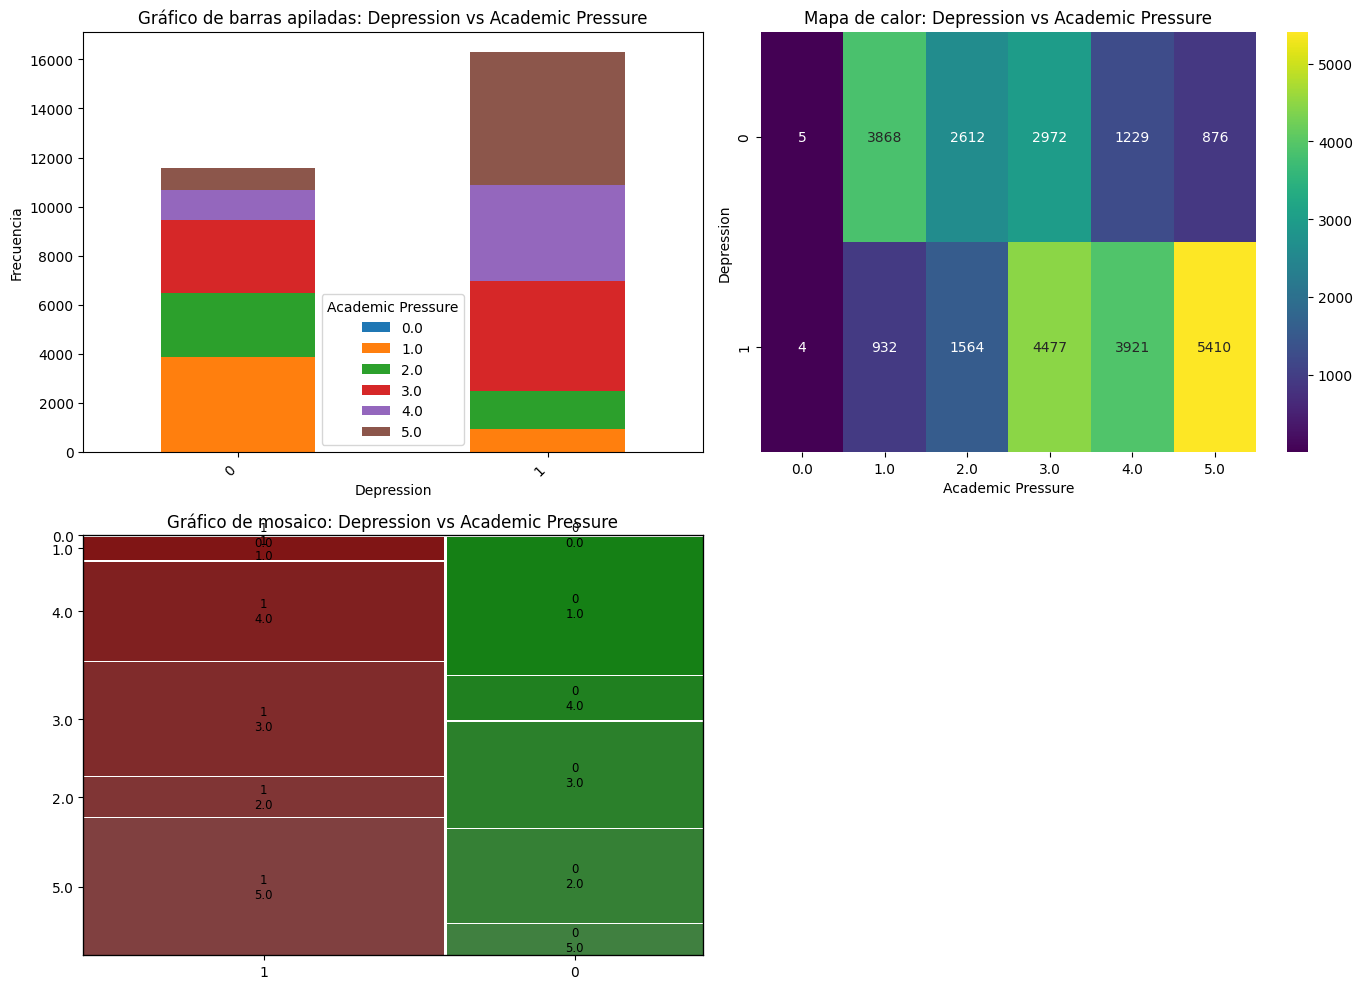

In [81]:
df = csvFile_copia
analisis_bivariado(df, 'Depression', 'Academic Pressure', target=None)

**Conclusiones del análisis: Depression vs Academic Pressure**

1. Existe una asociación significativa
El valor de Chi-cuadrado = 6418.43 con un p-valor = 0.000 indica que hay una relación estadísticamente significativa entre la presión académica y la presencia de depresión.
Dado que el valor p < 0.05, rechazamos la hipótesis nula de independencia entre ambas variables.
2. Fuerza de la relación: Moderada
La V de Cramér = 0.3393 sugiere que la relación entre la presión académica y la depresión es moderada, lo cual es relevante desde el punto de vista práctico.
3. Distribución de casos:
Los estudiantes sin depresión (Depression = 0) están más concentrados en niveles bajos de presión académica (1.0, 2.0).
En contraste, los estudiantes con depresión (Depression = 1) se concentran en los niveles más altos de presión académica.
4. Visualización clara en los gráficos:
En el gráfico de barras apiladas, se observa que:
La mayoría de los estudiantes con presión 4.0 y 5.0 están en la categoría con depresión.
En el heatmap, se destaca la densidad en las celdas (3,1), (4,1), y (5,1), con más de 3900 casos cada una.
El gráfico de mosaico muestra cómo el ancho relativo de las categorías de presión cambia según haya o no depresión, reflejando visualmente la asociación.

En conclusión, a mayor presión académica, mayor proporción de casos con depresión.
La variable Presión Académica puede ser un factor de riesgo importante para la depresión en estudiantes.
Esta asociación debería considerarse al diseñar intervenciones preventivas y programas de bienestar mental en contextos educativos.

**Análisis de Depresión y pensamientos suicidas**


---



Análisis bivariado: Depression vs Have you ever had suicidal thoughts ?
Tabla de contingencia (frecuencias absolutas):
Have you ever had suicidal thoughts ?     No     Sí  Total
Depression                                                
No                                      7865   3697  11562
Sí                                      2374  13934  16308
Total                                  10239  17631  27870

Tabla de contingencia (porcentajes por fila):
Have you ever had suicidal thoughts ?    No    Sí
Depression                                       
No                                     68.0  32.0
Sí                                     14.6  85.4

Prueba Chi-cuadrado:
Chi2: 8319.4082
Valor p: 0.0000
Grados de libertad: 1
Las variables están relacionadas (p < 0.05)
V de Cramér: 0.3863
Relación moderada


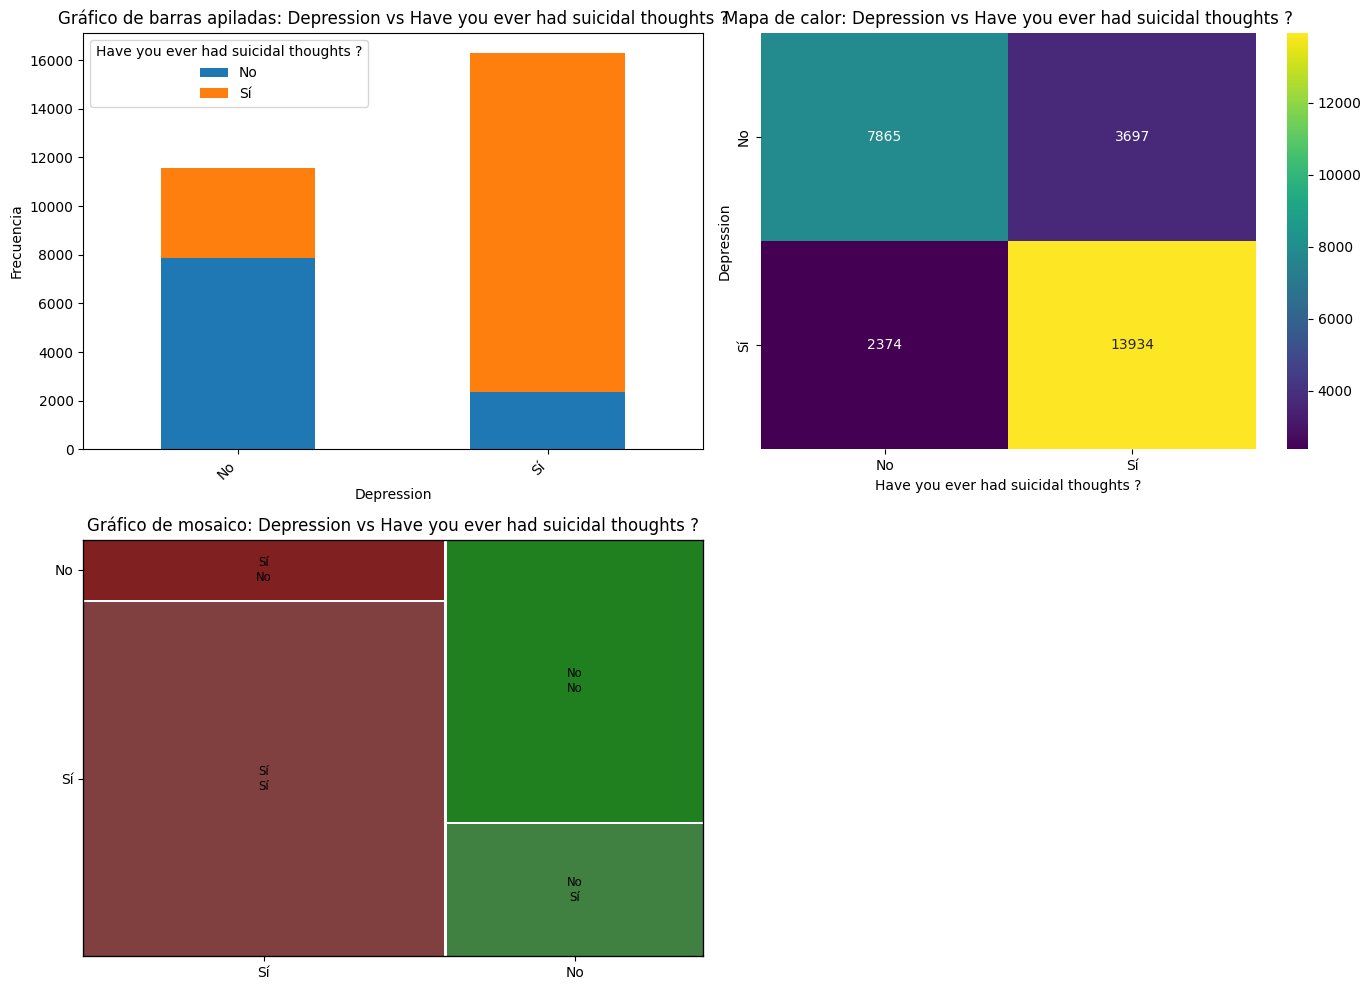

In [82]:
# 0. Crear una copia para no alterar el df original
df_mapped = df.copy()

# 1. Mapear 0->'No', 1->'Sí' en las dos variables
mapping = {0: 'No', 1: 'Sí'}
df_mapped['Depression'] = df_mapped['Depression'].map(mapping)
df_mapped['Have you ever had suicidal thoughts ?'] = (
    df_mapped['Have you ever had suicidal thoughts ?']
    .map(mapping)
)

# 2. Llamar a la función sobre el df ya mapeado
analisis_bivariado(
    df_mapped,
    'Depression',
    'Have you ever had suicidal thoughts ?',
    target=None
)

# analisis_bivariado(df, 'Depression', 'Have you ever had suicidal thoughts ?', target=None)

Conclusiones del análisis: Depression vs Suicidal Thoughts

1. Existe una asociación significativa
El valor de Chi² = 8319.41 con p = 0.0000 indica que hay una relación estadísticamente significativa entre haber tenido pensamientos suicidas y la presencia de depresión.

Se rechaza la hipótesis nula: las variables no son independientes.

2. Fuerza de la relación: Moderada
La V de Cramér = 0.3863, siendo una relación más fuerte que la encontrada con presión académica (0.3393), sugiere una asociación moderada, especialmente considerando que es una tabla de 2x2 (máxima V = 1).

3. Distribución de casos:
Entre quienes no tienen depresión, el 68% nunca tuvo pensamientos suicidas y el 32% sí los tuvo.

Entre quienes sí tienen depresión, el 85.4% ha tenido pensamientos suicidas, lo cual es una proporción muy alta.

Este contraste refuerza la idea de que los pensamientos suicidas están fuertemente asociados con la depresión.

4. Gráficos:
En el gráfico de barras apiladas, se observa que la mayoría de los casos de depresión se agrupan fuertemente en el grupo con pensamientos suicidas.

El heatmap refleja con claridad que las combinaciones (1,1) y (0,0) tienen los mayores recuentos, y el cruce (1,1) destaca especialmente con 13.934 casos.

El gráfico de mosaico visualiza que el mayor volumen se concentra en la celda donde ambas variables son 1, mostrando un solapamiento evidente.

**Análisis de Depresión y región**


---


Análisis bivariado: Depression vs Region
Tabla de contingencia (frecuencias absolutas):
Region      Centro  Desconocido  Este  Norte  Oeste   Sur  Total
Depression                                                      
No             896           11  1109   4005   4024  1517  11562
Sí            1331           14  1648   5159   5716  2440  16308
Total         2227           25  2757   9164   9740  3957  27870

Tabla de contingencia (porcentajes por fila):
Region      Centro  Desconocido  Este  Norte  Oeste   Sur
Depression                                               
No             7.7          0.1   9.6   34.6   34.8  13.1
Sí             8.2          0.1  10.1   31.6   35.1  15.0

Prueba Chi-cuadrado:
Chi2: 38.1571
Valor p: 0.0000
Grados de libertad: 5
Las variables están relacionadas (p < 0.05)
V de Cramér: 0.0262
Relación muy débil


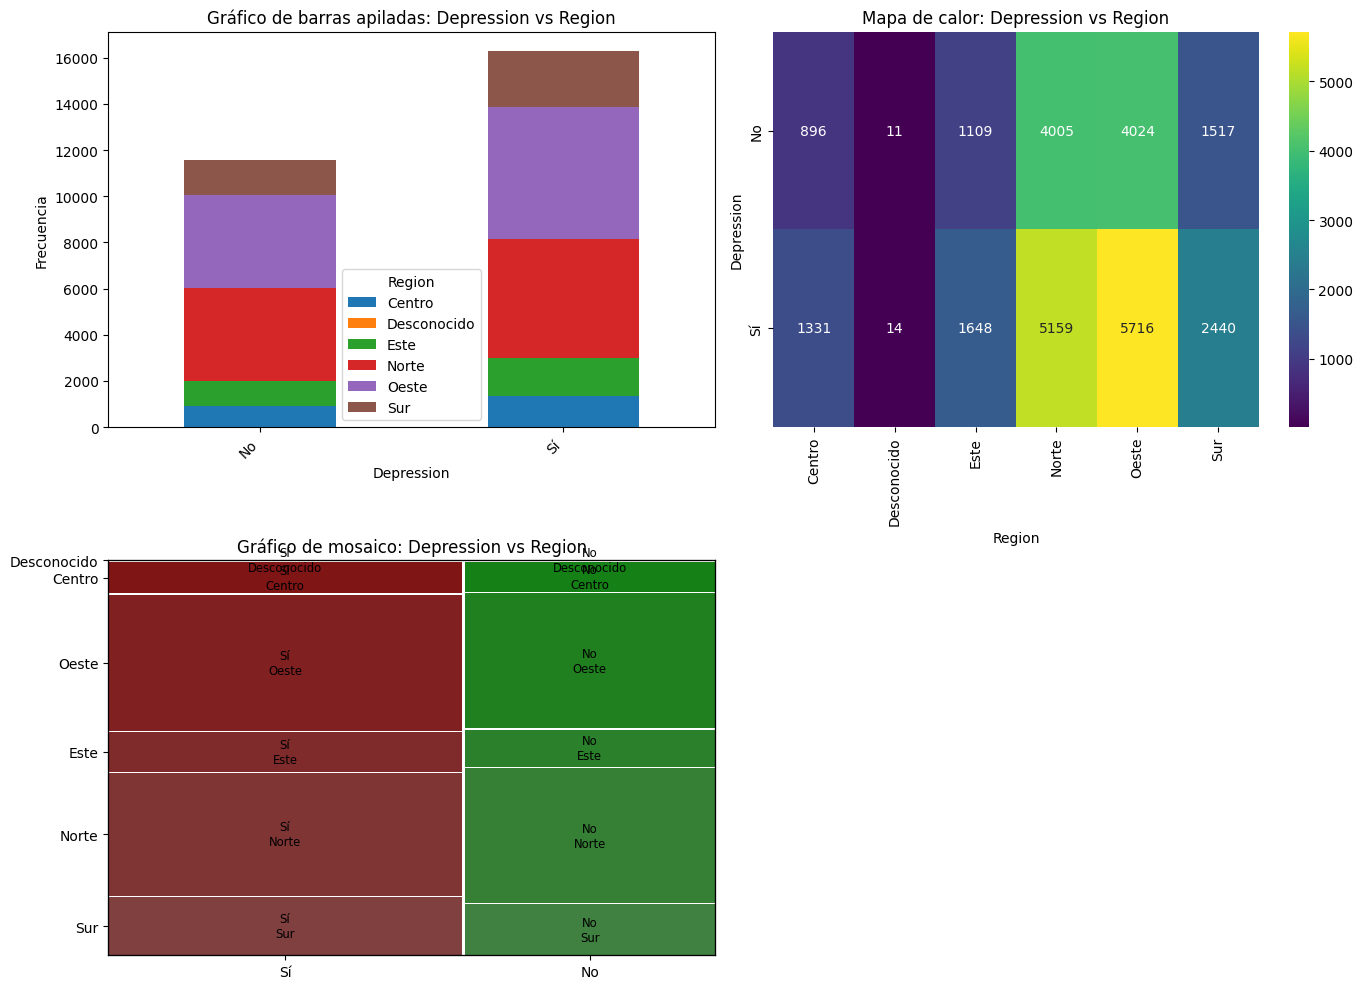

In [83]:
# 1. Copia el df original
df_mapped = df.copy()

# 2. Mapea Depression: 0 → 'No', 1 → 'Sí'
df_mapped['Depression'] = df_mapped['Depression'].map({0: 'No', 1: 'Sí'})

# 3. Llamá al análisis bivariado con Region
analisis_bivariado(
    df_mapped,
    'Depression',
    'Region',
    target=None
)

# analisis_bivariado(df, 'Depression', 'Region', target=None)

Conclusiones del análisis: Depression vs Region
1. Existe una asociación estadísticamente significativa (pero débil)
El valor de Chi² = 38.16 y un p = 0.0000 indica que hay relación entre la región y la presencia de depresión, pero...

El valor de V de Cramér = 0.0262 nos dice que esta relación es muy débil en términos prácticos.

Es decir, la región geográfica apenas influye en la probabilidad de tener depresión.

2. Distribución por regiones: diferencias leves
Las regiones Oeste y Norte tienen los mayores valores absolutos tanto en personas con como sin depresión (más de 4.000 casos en ambas categorías).

El porcentaje de personas con depresión es ligeramente mayor en el Sur, Este y Centro que en Norte/Oeste, pero las diferencias son marginales.

Ej: 15% de los casos sin depresión son del Sur, vs 13.1% de los casos con depresión.

3. Gráficos:
En el heatmap y el gráfico de barras apiladas, se observa que:

La distribución de personas con y sin depresión es bastante similar entre regiones.

El gráfico de mosaico lo representa claramente: la proporción de celdas por región es bastante pareja entre categorías de depresión.

Aunque la relación entre región y depresión es estadísticamente significativa, no es relevante desde el punto de vista clínico o de políticas públicas por su baja magnitud.

La región geográfica no parece ser un buen predictor o factor de riesgo directo para la depresión en este análisis.



**Análisis de Depresión y hábitos alimenticios**


---


Análisis bivariado: Depression vs Dietary Habits
Tabla de contingencia (frecuencias absolutas):
Dietary Habits  Healthy  Moderate  Unhealthy  Others  Total
Depression                                                 
0                  4176      4362       3020       4  11562
1                  3463      5548       7289       8  16308
Total              7639      9910      10309      12  27870

Tabla de contingencia (porcentajes por fila):
Dietary Habits  Healthy  Moderate  Unhealthy  Others
Depression                                          
0                  36.1      37.7       26.1     0.0
1                  21.2      34.0       44.7     0.0

Prueba Chi-cuadrado:
Chi2: 1204.3559
Valor p: 0.0000
Grados de libertad: 3
Las variables están relacionadas (p < 0.05)
V de Cramér: 0.1470
Relación débil


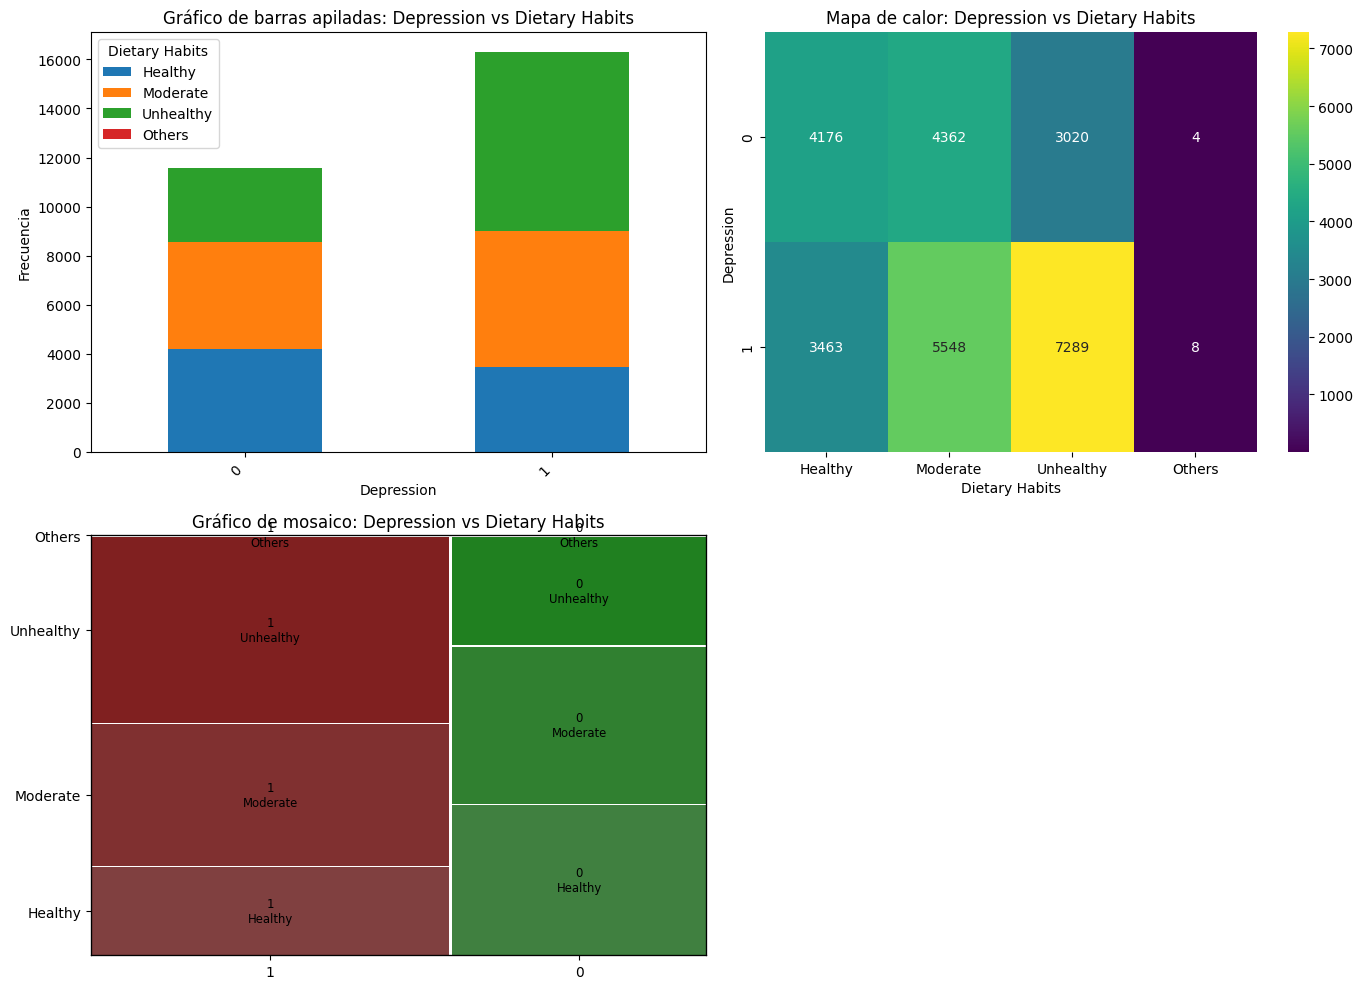

In [84]:
analisis_bivariado(df, 'Depression', 'Dietary Habits', target=None)


Conclusiones del análisis: Depression vs Dietary Habits

1. Existe una relación estadísticamente significativa
El valor de Chi² = 1204.28 y un p-valor = 0.0000 indican que hay una relación significativa entre los hábitos alimenticios y la presencia de depresión.

La V de Cramér = 0.1470 señala una relación débil, pero más fuerte que la observada con la variable "Region".

2. Distribución de casos: tendencia clara
Las personas sin depresión se distribuyen principalmente entre hábitos saludables (36.1%) y moderados (37.7%), y menos en hábitos no saludables (26.2%).

Las personas con depresión se concentran más en hábitos no saludables (44.7%), con menos frecuencia en hábitos saludables (21.2%).

3. Gráficos:
En el gráfico de barras apiladas, se ve cómo los hábitos no saludables son más comunes en personas con depresión, mientras que los saludables predominan en personas sin depresión.

El heatmap refuerza esto visualmente, mostrando una gran cantidad de casos de depresión entre quienes tienen hábitos no saludables.

El gráfico de mosaico también lo ilustra bien: los bloques más grandes están en la combinación de "Depresión = 1" + "Unhealthy".

En síntesis:
Existe una relación negativa entre la calidad de la dieta y la salud mental.

Los hábitos alimenticios no saludables están asociados a una mayor prevalencia de depresión, lo que coincide con literatura científica sobre el eje intestino-cerebro y el rol de la nutrición en la salud mental.

Aunque la relación es estadísticamente débil, es relevante para diseñar programas de intervención preventiva o educativa en contextos escolares, universitarios y de salud pública.


**Análisis de Depresión y Nivel educativo**


---


Análisis bivariado: Depression vs Degree_level
Tabla de contingencia (frecuencias absolutas):
Degree_level  High School  Bachelor  Master   Phd  Total
Depression                                              
0                    1777      5540    3430   801  11548
1                    4303      7084    3916   984  16287
Total                6080     12624    7346  1785  27835

Tabla de contingencia (porcentajes por fila):
Degree_level  High School  Bachelor  Master  Phd
Depression                                      
0                    15.4      48.0    29.7  6.9
1                    26.4      43.5    24.0  6.0

Prueba Chi-cuadrado:
Chi2: 496.7786
Valor p: 0.0000
Grados de libertad: 3
Las variables están relacionadas (p < 0.05)
V de Cramér: 0.0945
Relación muy débil


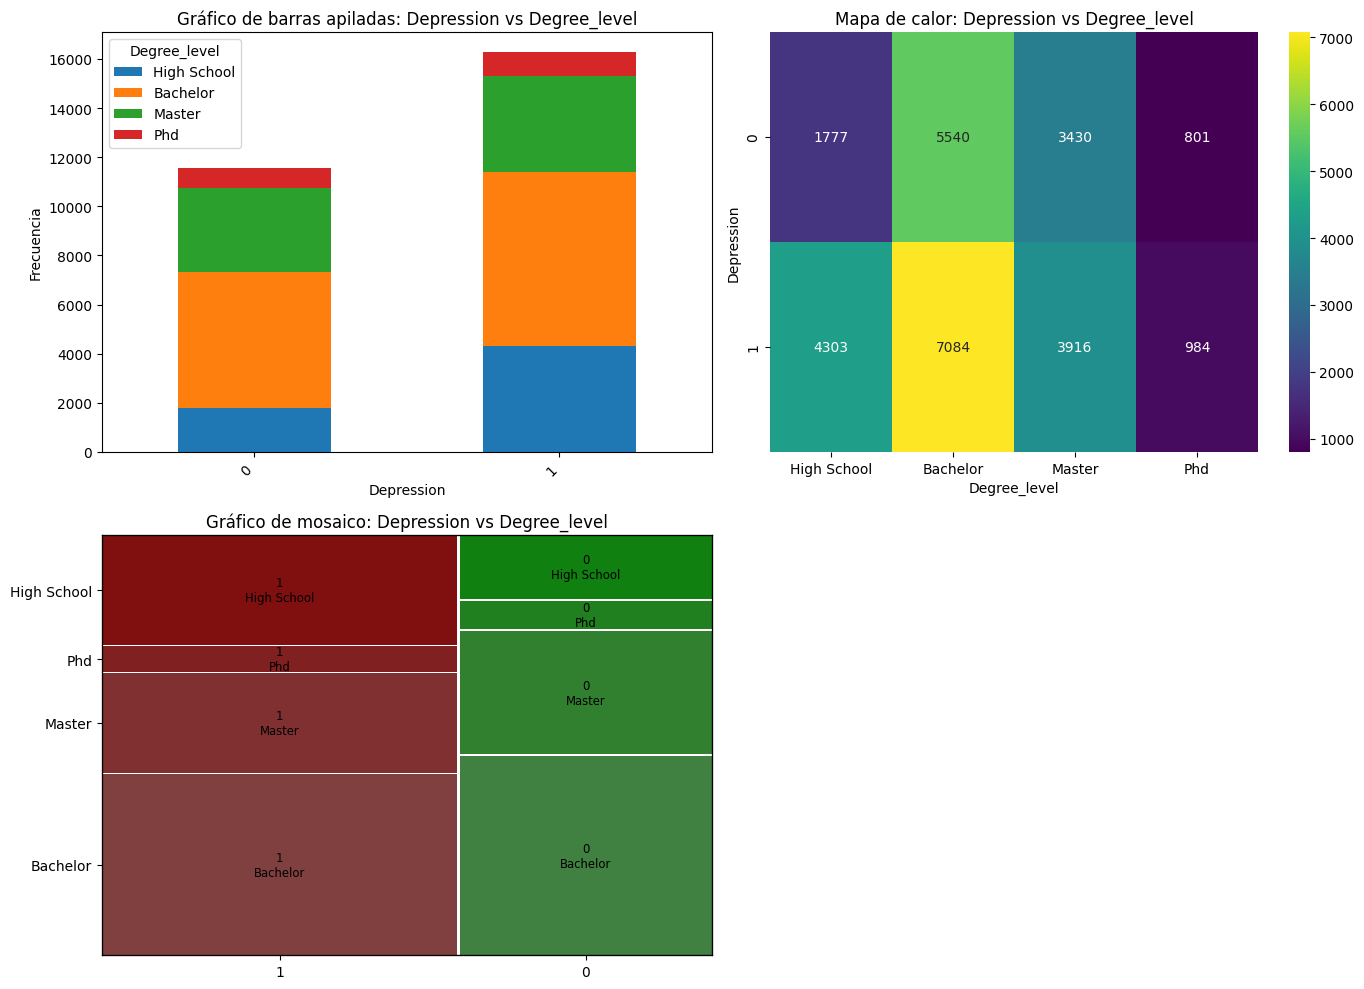

In [85]:
 analisis_bivariado(df, 'Depression', 'Degree_level', target=None)

Conclusiones del análisis: Depression vs Degree Level
1. Existe una asociación estadísticamente significativa
El valor de Chi² = 496.6 y un p-valor = 0.0000 indican que la variable nivel educativo y depresión están relacionadas estadísticamente.

Sin embargo, la V de Cramér = 0.0944 revela que esta es una relación muy débil.

2. Distribución de casos según nivel educativo
Los casos sin depresión se concentran más en personas con título de grado (48%), seguidos por maestría (29.7%) y secundaria (15.4%).

En cambio, entre los que sí tienen depresión, la proporción de personas con solo secundaria aumenta notablemente al 26.4%.

Esto sugiere que a menor nivel educativo, aumenta la proporción de casos con depresión.

3. Gráficos:
El gráfico de barras apiladas y el mosaico muestran cómo la categoría High School tiene un peso mayor dentro del grupo con depresión, comparado con el grupo sin depresión.

El heatmap lo evidencia con claridad: en High School hay 4303 personas con depresión vs. 1777 sin depresión, casi 2.5 veces más.

En síntesis:
Aunque hay una tendencia a que las personas con menor nivel educativo tengan más casos de depresión, esta asociación es estadísticamente significativa pero débil en la práctica.

Esto indica que el nivel educativo no es un factor determinante de por sí, pero podría estar vinculado a otros factores socioeconómicos que sí influyen más directamente.



**Análisis de Depresión y Duración de sueño**


---

Análisis bivariado: Depression vs Sleep Duration
Tabla de contingencia (frecuencias absolutas):
Sleep Duration  Less than 5 hours  5-6 hours  7-8 hours  More than 8 hours  \
Depression                                                                   
0                            2949       2664       2975               2965   
1                            5354       3513       4362               3070   
Total                        8303       6177       7337               6035   

Sleep Duration  Others  Total  
Depression                     
0                    9  11562  
1                    9  16308  
Total               18  27870  

Tabla de contingencia (porcentajes por fila):
Sleep Duration  Less than 5 hours  5-6 hours  7-8 hours  More than 8 hours  \
Depression                                                                   
0                            25.5       23.0       25.7               25.6   
1                            32.8       21.5       26.7               18

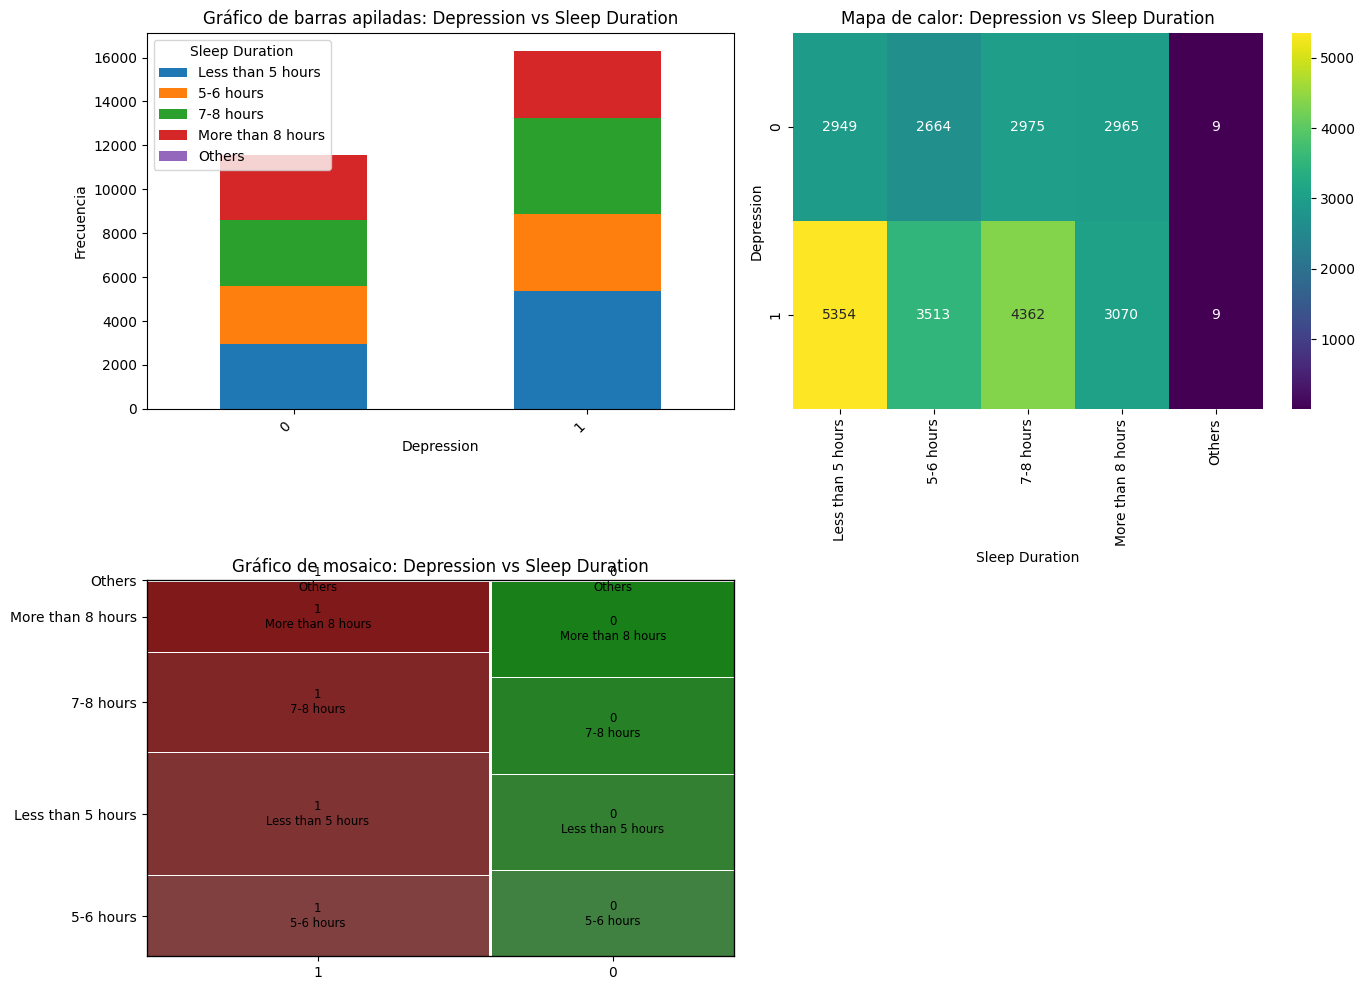

In [86]:
analisis_bivariado(df, 'Depression', 'Sleep Duration', target=None)

Conclusiones del análisis: Depression vs Sleep Duration

1. Relación estadísticamente significativa pero muy débil
La prueba Chi² = 277.18, con un valor p = 0.0000, indica una relación estadísticamente significativa entre la duración del sueño y la presencia de depresión.

Sin embargo, la V de Cramér = 0.0705 muestra que esta relación es muy débil desde el punto de vista práctico.

2. Distribución de casos y tendencias observadas
Las personas con depresión (Depression = 1) tienen una mayor proporción de sueño corto:

32.8% duermen menos de 5 horas, comparado con solo 25.5% en personas sin depresión.

Solo el 18.8% de personas con depresión duerme más de 8 horas, frente al 25.6% entre quienes no la tienen.

Las categorías “7–8 horas” y “5–6 horas” están distribuidas de forma más pareja, aunque también muestran mayor depresión en las franjas de menor descanso.

3. Visualización
El gráfico de barras apiladas y el heatmap destacan el grupo con menos de 5h de sueño como el que más casos de depresión concentra.

El gráfico de mosaico refuerza visualmente que las proporciones de depresión aumentan conforme la duración del sueño disminuye.

En síntesis:
Aunque la asociación es débil, el patrón es coherente y consistente con evidencia en salud mental: menos horas de sueño están asociadas con una mayor prevalencia de depresión.

Esta relación sugiere que la duración del sueño puede ser un factor de riesgo indirecto, útil para monitorear e intervenir en poblaciones vulnerables.

**Análisis de duración de sueño y nivel educativo, por Depresión**


---

Análisis bivariado: Sleep Duration vs Degree_level
Tabla de contingencia (frecuencias absolutas):
Degree_level       High School  Bachelor  Master   Phd  Total
Sleep Duration                                               
Less than 5 hours         1803      3814    2133   541   8291
5-6 hours                 1309      2846    1618   399   6172
7-8 hours                 1561      3300    1991   475   7327
More than 8 hours         1407      2654    1598   368   6027
Others                       0        10       6     2     18
Total                     6080     12624    7346  1785  27835

Tabla de contingencia (porcentajes por fila):
Degree_level       High School  Bachelor  Master   Phd
Sleep Duration                                        
Less than 5 hours         21.7      46.0    25.7   6.5
5-6 hours                 21.2      46.1    26.2   6.5
7-8 hours                 21.3      45.0    27.2   6.5
More than 8 hours         23.3      44.0    26.5   6.1
Others                     0.

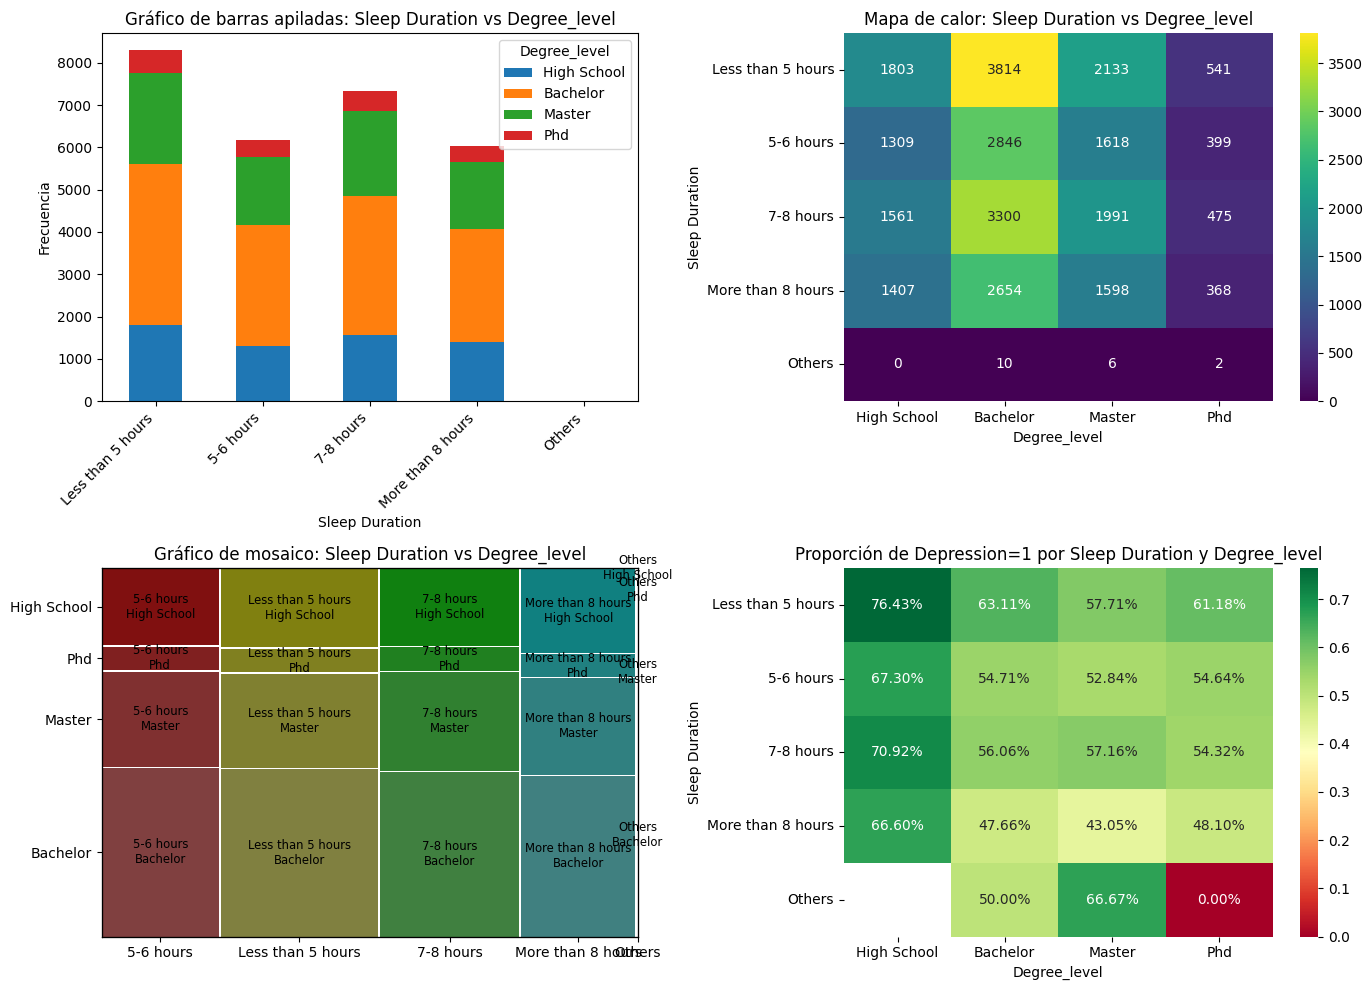

In [87]:
#print(df.columns)


analisis_bivariado(df, 'Sleep Duration', 'Degree_level', target='Depression')

Observamos una relación muy débil entre estas variables, por lo tanto, no profundizaremos en este análisis.

**Análisis de duración de sueño y hábitos alimenticios, por Depresión**


---

Análisis bivariado: Sleep Duration vs Dietary Habits
Tabla de contingencia (frecuencias absolutas):
Dietary Habits     Healthy  Moderate  Unhealthy  Others  Total
Sleep Duration                                                
Less than 5 hours     2195      3037       3066       5   8303
5-6 hours             1781      2214       2179       3   6177
7-8 hours             2006      2511       2817       3   7337
More than 8 hours     1654      2141       2239       1   6035
Others                   3         7          8       0     18
Total                 7639      9910      10309      12  27870

Tabla de contingencia (porcentajes por fila):
Dietary Habits     Healthy  Moderate  Unhealthy  Others
Sleep Duration                                         
Less than 5 hours     26.4      36.6       36.9     0.1
5-6 hours             28.8      35.8       35.3     0.0
7-8 hours             27.3      34.2       38.4     0.0
More than 8 hours     27.4      35.5       37.1     0.0
Others       

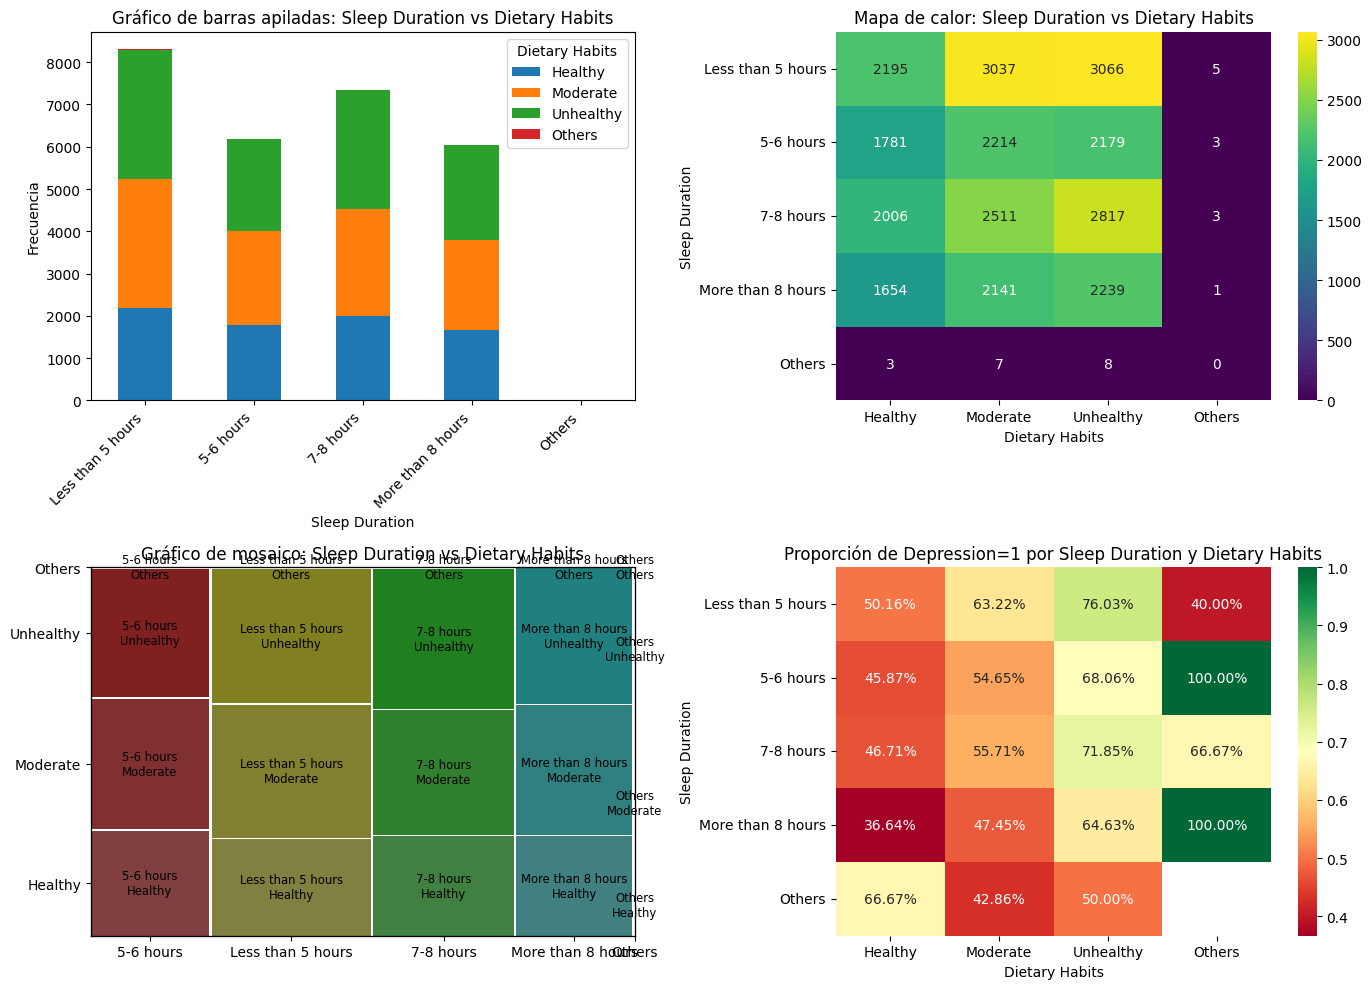

In [88]:
analisis_bivariado(df, 'Sleep Duration', 'Dietary Habits', target='Depression')

Al igual que en el gráfico anterior, observamos una relación muy débil.

**Test de Spearman**

In [89]:


columnas_no_numericas = csvFile_copia.select_dtypes(exclude=['int', 'float']).columns
iris_numerico = csvFile_copia.drop(columnas_no_numericas, axis=1)

print("\n=== Matriz de correlación (Spearman) ===")
corr_matrix = iris_numerico.corr(method='spearman')
print(corr_matrix)


=== Matriz de correlación (Spearman) ===
                                             id       Age  Academic Pressure  \
id                                     1.000000  0.004345           0.004912   
Age                                    0.004345  1.000000          -0.077019   
Academic Pressure                      0.004912 -0.077019           1.000000   
CGPA                                  -0.011115  0.007183          -0.024565   
Study Satisfaction                     0.007979  0.008240          -0.115871   
Have you ever had suicidal thoughts ?  0.004576 -0.113126           0.259575   
Study Hours                           -0.003571 -0.029005           0.091477   
Financial Stress                       0.000347 -0.095737           0.150086   
Family History of Mental Illness      -0.005272 -0.006114           0.029887   
Depression                             0.001031 -0.225632           0.472370   

                                           CGPA  Study Satisfaction  \
id    

Análisis centrado en Depresión:

| Variable                                  | Correlación con Depresión |                                                 |
| ----------------------------------------- | ------------------------- | -------------------------------------------------------------- |
| *Have you ever had suicidal thoughts ?* | *0.546*                 |              |
| *Academic Pressure*                     | *0.472*                 |         |
| *Financial Stress*                      | *0.363*                 |             |
| *Study Hours*                           | 0.201                     |          |
| *Family History of Mental Illness*      | 0.053                     |                    |
| *CGPA (promedio académico)*             | 0.022                     |                    |
| *Study Satisfaction*                    | *-0.168*                |  |
| *Age*                                   | *-0.226*                |       |

Otros patrones destacados
Suicidal Thoughts también está correlacionado con:

* Academic Pressure (0.260)

* Financial Stress (0.209)

* Study Hours (0.117)

Esto sugiere un clúster de variables de carga académica (presión, estrés financiero, horas de estudio) que están relacionadas tanto con depresión como con pensamientos suicidas.

La edad presenta una correlación negativa con varios factores estresantes:

Con Depression, Academic Pressure, Financial Stress y Suicidal Thoughts, lo cual podría reflejar un mayor nivel de adaptación o resiliencia en personas mayores.

## Síntesis

En defnintiva, las variables más relevantes para explicar la depresión son:

* Pensamientos suicidas (0.55)

* Presión académica (0.47)

* Estrés financiero (0.36)

Aún así, no se observan correlaciones fuertes sino moderadas y moderadas-bajas.

Variables protectoras (con correlación negativa):

* Edad (-0.23)

* Satisfacción con el estudio (-0.17)

Sin embargo, se obesrva que la correlacion es débil para ambas variables.

Variables no relevantes:

* CGPA (rendimiento académico)

Historial familiar de salud mental

* ID (sin sentido interpretativo)


In [90]:
# # --- MAPA DE CALOR DE CORRELACIÓN SPEARMAN---
# plt.figure(figsize=(8, 6))
# sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
# plt.title("Matriz de correlación Spearman")
# plt.show()

**Test de Pearson**

In [91]:
# --- MATRIZ DE CORRELACIÓN ---
print("\n=== Matriz de correlación (Pearson) ===")
corr_matrix = iris_numerico.corr()
print(corr_matrix)


=== Matriz de correlación (Pearson) ===
                                             id       Age  Academic Pressure  \
id                                     1.000000  0.004032           0.005181   
Age                                    0.004032  1.000000          -0.075871   
Academic Pressure                      0.005181 -0.075871           1.000000   
CGPA                                  -0.011498  0.005213          -0.025040   
Study Satisfaction                     0.007861  0.009131          -0.110903   
Have you ever had suicidal thoughts ?  0.004579 -0.113654           0.261580   
Study Hours                           -0.004189 -0.032775           0.096291   
Financial Stress                       0.000876 -0.095251           0.151795   
Family History of Mental Illness      -0.005227 -0.004973           0.030122   
Depression                             0.001025 -0.226738           0.474805   

                                           CGPA  Study Satisfaction  \
id     

Análisis centrado en Depresión:

| Variable                                  | Correlación con Depresión |                                                 |
| ----------------------------------------- | ------------------------- | -------------------------------------------------------------- |
| *Have you ever had suicidal thoughts ?* | *0.546*                 |                |
| *Academic Pressure*                     | *0.475*                 |          |
| *Financial Stress*                      | *0.364*                 |                               |
| *Study Hours*                           | 0.209                     |        |
| *Family History of Mental Illness*      | 0.053                     |             |
| *CGPA*                                  | 0.022                     |          |
| *Study Satisfaction*                    | *-0.168*                |  |
| *Age*                                   | *-0.227*                |       |

Las variables más asociadas con depresión según el test de Pearson son:

* Pensamientos suicidas (0.546)

* Presión académica (0.47)

* Estrés financiero (0.36)

Las variables protectoras:

* Edad (correlación negativa)

* Satisfacción con el estudio (correlación negativa)

Variables poco o nada relevantes:

* CGPA (rendimiento académico)

* Historial familiar de enfermedad mental (ligeramente positivo pero muy débil)

**Comparación entre Spearman y Pearson**

Las matrices de Pearson y Spearman arrojan prácticamente los mismos resultados, lo que indica que las relaciones entre variables son lineales o casi lineales, sin grandes efectos no lineales.





**Matriz de correlación**

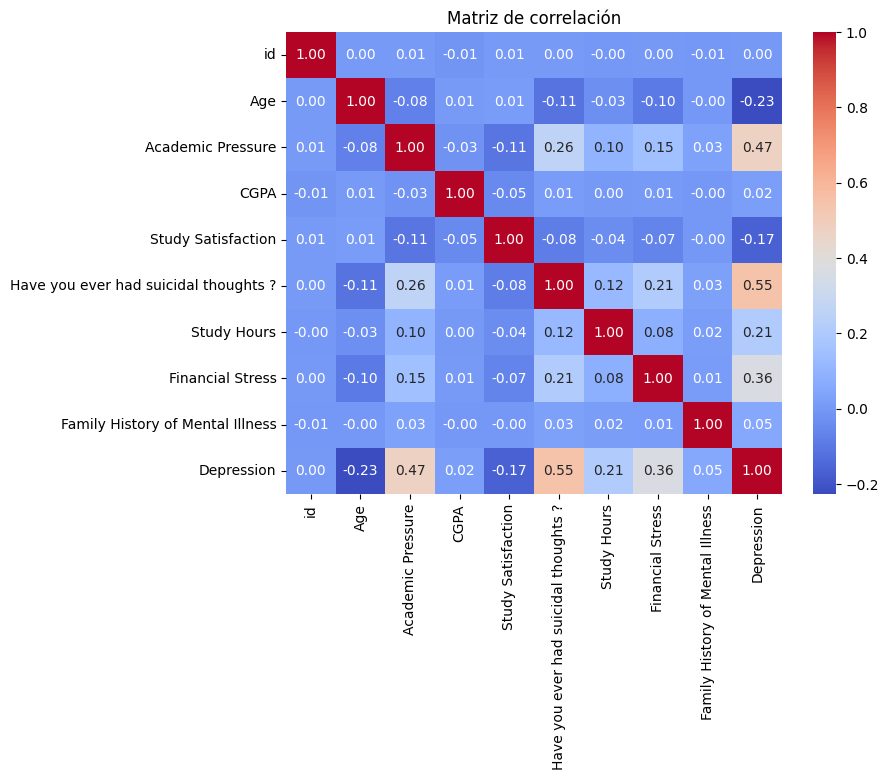

In [92]:
# --- MAPA DE CALOR DE CORRELACIÓN ---
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()


| Variable                                  | Correlación |                                   |
| ----------------------------------------- | ----------- | -------------------------------------------------- |
| *Have you ever had suicidal thoughts ?* | *0.55*    | |
| *Academic Pressure*                     | *0.47*    ||
| *Financial Stress*                      | *0.36*    | |
| *Study Hours*                           | 0.21        | |
| *Study Satisfaction*                    | *-0.17*   ||
| *Age*                                   | *-0.23*   |  |
| *Family History of Mental Illness*      | 0.05        ||
| *CGPA (Promedio académico)*             | 0.02        |  |

Otras relaciones destacadas
Suicidal Thoughts también se correlaciona con:

* Academic Pressure (0.26)

* Financial Stress (0.21)

* Study Hours (0.12)

Estas variables parecen agruparse como un conjunto de factores de carga mental y emocional.

Study Satisfaction tiene correlaciones negativas con múltiples variables:

* Academic Pressure (-0.11)

* Suicidal Thoughts (-0.08)

* Depression (-0.17)

Lo que sugiere que mejorar la satisfacción académica puede tener efecto protector.


En conclusión, los factores con mayor valor predictivo para depresión son:

* Suicidal Thoughts

* Academic Pressure

* Financial Stress


Factores protectores (negativamente correlacionados):

* Edad

* Satisfacción con el estudio

Factores sin relevancia:

* Promedio académico (CGPA)

* Antecedentes familiares de enfermedad mental

**Análisis de correspondencias múltiples | Género, duración de sueño, hábitos alimenticios y Depresión**


---

In [93]:
## Relacion entre variables categoricas

categoricas = csvFile_copia.drop(['Age', 'Degree_level', 'Region', 'CGPA', 'Profession', 'Financial Stress', 'id', 'Study Satisfaction','Degree', 'Academic Pressure', 'Have you ever had suicidal thoughts ?', 'Study Hours', 'Family History of Mental Illness', 'City'], axis=1)

# Convierto Depresion a no numerica
categoricas['Depression'] = categoricas['Depression'].map({0: 'No', 1: 'Sí'})

categoricas.isnull().sum()

,0
Gender,0
Sleep Duration,0
Dietary Habits,0
Depression,0


In [94]:

# Create instance MCA
mca = MCA(
    n_components=2,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='auto',
    random_state=42)

# Ajustar el modelo using the cleaned dataframe
mca_resultado = mca.fit(categoricas)

# Examinar valores propios
print("Valores propios:")
print(mca.eigenvalues_)

# Examinar varianza explicada por dimensión
print("\nVarianza explicada:")
print(mca.explained_inertia_)

# Coordenadas de las categorías
# Use the cleaned dataframe to get column coordinates
coord_categorias = mca.column_coordinates(categoricas)
print("\nCoordenadas de las categorías:")
print(coord_categorias)

# Coordenadas de los individuos
# Use the cleaned dataframe to get row coordinates
coord_individuos = mca.row_coordinates(categoricas)
print("\nCoordenadas de los individuos:")
print(coord_individuos)

Valores propios:
[0.3103414091457585, 0.2588306792171298]

Varianza explicada:
[0.13792951517589266, 0.11503585742983548]

Coordenadas de las categorías:
                                         0         1
Gender_Female                     0.217470  0.697670
Gender_Male                      -0.172825 -0.554443
Sleep Duration_Less than 5 hours -0.418140  0.597253
Sleep Duration_5-6 hours          0.235175  0.375840
Sleep Duration_7-8 hours         -0.113850 -0.181288
Sleep Duration_More than 8 hours  0.473019 -0.989972
Sleep Duration_Others            -0.011511  1.335255
Dietary Habits_Healthy            0.919254 -0.187518
Dietary Habits_Moderate           0.182211  0.662722
Dietary Habits_Unhealthy         -0.855014 -0.501572
Dietary Habits_Others            -1.128869  2.965007
Depression_No                     0.899151 -0.192425
Depression_Sí                    -0.637478  0.136425

Coordenadas de los individuos:
              0         1
0      0.154432 -0.112872
1      0.688410  0.7

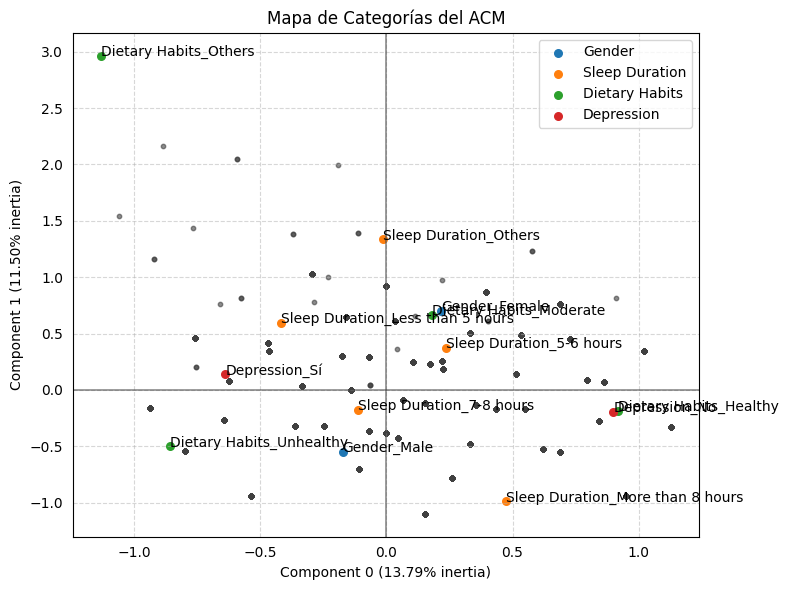

In [95]:
# Gráfico de dimensiones principales (categorías)
ax = mca.plot_coordinates(
    X=categoricas,
    ax=None,
    figsize=(8, 6),
    show_row_points=True,
    row_points_size=10,
    show_row_labels=False,
    show_column_points=True,
    column_points_size=30,
    show_column_labels=True,
    legend_n_cols=1)
plt.title('Mapa de Categorías del ACM')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


#Resumen del ACM

Inercia:
Las dos primeras dimensiones del Análisis de Correspondencias Múltiples (ACM) explican conjuntamente el 25.29% de la inercia total del sistema, con la Dimensión 1 aportando un 13.79% y la Dimensión 2 un 11.50%.

Por tanto, aunque el gráfico de categorías permite identificar tendencias relevantes y asociaciones destacadas (especialmente las más extremas o bien separadas), es importante tener en cuenta que representa una simplificación parcial del espacio multidimensional total.

Varianza explicada:

Dimensión 1 (13.79%) parece capturar diferencias relacionadas con la calidad de los hábitos alimenticios y de sueño.

Dimensión 2 (11.50%) captura aspectos más vinculados a género y extremos en patrones de sueño y salud.

### Interpretaciones:

| Categoría           | Observación clave                                                                                                    |
| ------------------- | -------------------------------------------------------------------------------------------------------------------- |
| Less than 5 hours | Cuadrante sup. izquierdo — se aleja del centro, asociado con **Depresión\_Sí**.                                      |
| 5–6 hours         | Algo más cercano al centro, pero hacia cuadrante positivo, también en dirección a depresión.                         |
| 7–8 hours         | Cercano al origen → indica **perfil típico**, neutro, sin asociación marcada.                                        |
| More than 8 hours | Cuadrante inf. derecho → alejado, **perfil atípico**, probablemente de baja frecuencia. Asocia con **no depresión**. |
| Others            | Muy alejado en Dim 2. Posiblemente mal categorizado o poco frecuente, afecta poco la interpretación global.          |

Menos horas de sueño (especialmente <5h) se asocian a Depresión_Sí. El perfil típico (7–8h) se alinea con Depresión_No.

| Categoría   | Observación clave                                                                    |
| ----------- | ------------------------------------------------------------------------------------ |
| Healthy   | Muy alineado con Depression_No → asociación clara positiva.                        |
| Unhealthy | En dirección opuesta → asociado a Depression_Sí.                                   |
| Moderate  | Más neutro, entre los dos extremos.                                                  |
| Others    | Extremadamente alejado (Dim 2 alta), representa un **grupo marginal o heterogéneo**. |



Existe una asociación directa entre hábitos alimenticios saludables y menor prevalencia de depresión. Lo contrario ocurre con hábitos no saludables.

| Género   | Observación clave                                                                                               |
| -------- | --------------------------------------------------------------------------------------------------------------- |
| Female | Arriba a la derecha, cerca de Moderate, 5-6h y Less than 5h → tendencia a reportar más estrés y síntomas. |
| Male   | Más cercano a Unhealthy y Depression_Sí.                                                                    |



Aunque el efecto del género es más tenue, los hombres parecen más cercanos a perfiles con mayor prevalencia de depresión en este análisis.

| Categoría       | Observación clave                                        |
| --------------- | -------------------------------------------------------- |
| Depression_No | Cercano a Healthy y 7–8h. Perfil saludable y típico. |
| Depression_Sí | Cercano a Unhealthy, Male, y Less than 5h.         |

Depresión se asocia a la combinación de:

- Menor cantidad de sueño,

- Hábitos alimenticios no saludables,

- Y en menor medida, al género masculino.

## Síntesis general

-El ACM revela una estructura clara de asociación entre categorías:

-Cluster protector: Dietary Habits_Healthy + Sleep Duration_7-8 hours + Depression_No

-Cluster de riesgo: Dietary Habits_Unhealthy + Less than 5 hours + Depression_Sí

-Género y categorías como Others en sueño o dieta se sitúan como más neutros o marginales, sin tanto peso explicativo.

**Análisis de similitud**



---



In [96]:
# import pandas as pd
# import numpy as np


# ----------------------------
# 1. Carga y preparación básica
# ----------------------------
df = csvFile_copia.copy()

# Mapear sueño
sleep_map = {
    "Less than 5 hours": 4.5,
    "5-6 hours": 5.5,
    "7-8 hours": 7.5,
    "More than 8 hours": 9.0,
    "Others": 6.5
}
df['Sleep Duration'] = df['Sleep Duration'].map(sleep_map)

# Codificación
df['Dietary Habits'] = LabelEncoder().fit_transform(df['Dietary Habits'])
df['Family History of Mental Illness'] = LabelEncoder().fit_transform(df['Family History of Mental Illness'])
df['Degree_level'] = LabelEncoder().fit_transform(df['Degree_level'])

# Variables seleccionadas
features_cols = ['Academic Pressure', 'CGPA', 'Sleep Duration',
                 'Dietary Habits', 'Study Hours', 'Degree_level']

# -------------------------------------
# 2. Elegir un estudiante objetivo con depresión
# -------------------------------------
est_objetivo = df[df['Depression'] == 1].sample(1, random_state=1)
X_objetivo = est_objetivo[features_cols].values
id_objetivo = est_objetivo['id'].values[0]

# -------------------------------------
# 3. Comparar contra una muestra liviana
# -------------------------------------
df_muestra = df[df['id'] != id_objetivo].sample(n=300, random_state=2).copy()
X_muestra = df_muestra[features_cols].values
ids_muestra = df_muestra['id'].astype(str).values

# -------------------------------------
# 4. Calcular similitudes
# -------------------------------------

# Coseno (opcional)
cos_sim = cosine_similarity(X_objetivo, X_muestra)[0]

# Euclidiana
euc_sim = 1 / (1 + euclidean_distances(X_objetivo, X_muestra)[0])

# Manhattan
man_sim = 1 / (1 + manhattan_distances(X_objetivo, X_muestra)[0])

# Jaccard (con binarización)
X_bin_obj = (X_objetivo >= np.median(X_muestra, axis=0)).astype(int)[0]
X_bin_muestra = (X_muestra >= np.median(X_muestra, axis=0)).astype(int)

jaccard_sim = np.array([jaccard_score(X_bin_obj, row) for row in X_bin_muestra])

# -------------------------------------
# 5. Mostrar top similares
# -------------------------------------
def mostrar_top_similares(ids, sims, metodo):
    top_idx = sims.argsort()[::-1][:5]
    print(f"\nTop 5 estudiantes más similares a ID {id_objetivo} usando {metodo}:")
    for i in top_idx:
        print(f"  ID {ids[i]} → Similitud: {sims[i]:.3f}")

mostrar_top_similares(ids_muestra, cos_sim, "Coseno")
mostrar_top_similares(ids_muestra, euc_sim, "Euclidiana")
mostrar_top_similares(ids_muestra, man_sim, "Manhattan")
mostrar_top_similares(ids_muestra, jaccard_sim, "Jaccard")



Top 5 estudiantes más similares a ID 10130 usando Coseno:
  ID 91863 → Similitud: 0.996
  ID 72183 → Similitud: 0.996
  ID 100147 → Similitud: 0.993
  ID 89577 → Similitud: 0.993
  ID 121319 → Similitud: 0.992

Top 5 estudiantes más similares a ID 10130 usando Euclidiana:
  ID 91863 → Similitud: 0.414
  ID 100147 → Similitud: 0.364
  ID 72183 → Similitud: 0.363
  ID 89577 → Similitud: 0.357
  ID 48341 → Similitud: 0.309

Top 5 estudiantes más similares a ID 10130 usando Manhattan:
  ID 91863 → Similitud: 0.328
  ID 48341 → Similitud: 0.242
  ID 100147 → Similitud: 0.238
  ID 72183 → Similitud: 0.233
  ID 89577 → Similitud: 0.223

Top 5 estudiantes más similares a ID 10130 usando Jaccard:
  ID 6274 → Similitud: 1.000
  ID 8527 → Similitud: 1.000
  ID 10630 → Similitud: 1.000
  ID 129011 → Similitud: 1.000
  ID 102382 → Similitud: 1.000


In [97]:
# --------------------------------
# Crear Series para visualización y análisis
# --------------------------------
cosine_series = pd.Series(cos_sim, index=ids_muestra)
euclidean_series = pd.Series(euc_sim, index=ids_muestra)
manhattan_series = pd.Series(man_sim, index=ids_muestra)
jaccard_series = pd.Series(jaccard_sim, index=ids_muestra)

# --------------------------------
# FUNCIÓN DE RECOMENDACIÓN ADAPTADA
# --------------------------------
def recomendar_usuario_similar_liviano(id_objetivo, similarity_series, method_name, top_n=5):
    similares = similarity_series.nlargest(top_n)
    print(f"\nEstudiantes más similares a ID {id_objetivo} usando {method_name}:")
    for idx, sim in similares.items():
        print(f"  ID {idx}: Similitud: {sim:.3f}")
    return similares

# --------------------------------
# EJECUCIÓN: estudiante objetivo contra muestra
# --------------------------------
similares_coseno = recomendar_usuario_similar_liviano(id_objetivo, cosine_series, "Coseno")
similares_euclidiana = recomendar_usuario_similar_liviano(id_objetivo, euclidean_series, "Euclidiana")
similares_manhattan = recomendar_usuario_similar_liviano(id_objetivo, manhattan_series, "Manhattan")
similares_jaccard = recomendar_usuario_similar_liviano(id_objetivo, jaccard_series, "Jaccard")




Estudiantes más similares a ID 10130 usando Coseno:
  ID 91863: Similitud: 0.996
  ID 72183: Similitud: 0.996
  ID 100147: Similitud: 0.993
  ID 89577: Similitud: 0.993
  ID 121319: Similitud: 0.992

Estudiantes más similares a ID 10130 usando Euclidiana:
  ID 91863: Similitud: 0.414
  ID 100147: Similitud: 0.364
  ID 72183: Similitud: 0.363
  ID 89577: Similitud: 0.357
  ID 48341: Similitud: 0.309

Estudiantes más similares a ID 10130 usando Manhattan:
  ID 91863: Similitud: 0.328
  ID 48341: Similitud: 0.242
  ID 100147: Similitud: 0.238
  ID 72183: Similitud: 0.233
  ID 89577: Similitud: 0.223

Estudiantes más similares a ID 10130 usando Jaccard:
  ID 6274: Similitud: 1.000
  ID 129011: Similitud: 1.000
  ID 77598: Similitud: 1.000
  ID 10630: Similitud: 1.000
  ID 91863: Similitud: 1.000


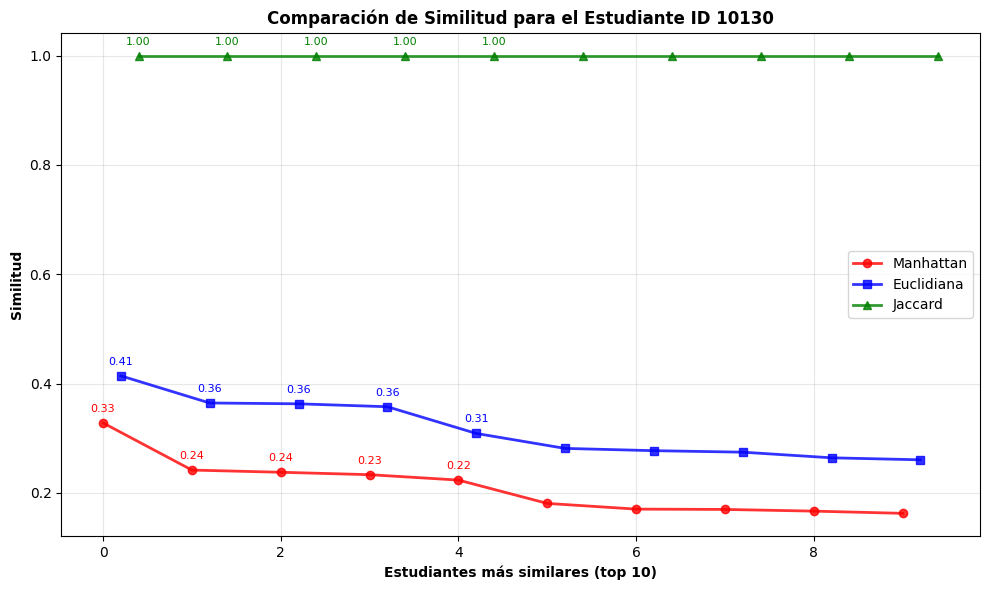

In [98]:
# --------------------------------
# VISUALIZACIÓN COMPARATIVA ADAPTADA
# --------------------------------

# Listas de similitudes ya calculadas como vectores
similarity_vectors = [man_sim, euc_sim, jaccard_sim]
method_names = ['Manhattan', 'Euclidiana', 'Jaccard']
colors = ['red', 'blue', 'green']
markers = ['o', 's', '^']

fig, ax = plt.subplots(figsize=(10, 6))

for i, (sims, method, color, marker) in enumerate(zip(similarity_vectors, method_names, colors, markers)):
    # Ordenar las similitudes en orden descendente
    orden = np.argsort(sims)[::-1]
    ids_ordenados = ids_muestra[orden]
    sims_ordenados = sims[orden]

    # Posiciones horizontales para diferenciar métodos
    pos = np.arange(len(sims_ordenados)) + i * 0.2
    ax.plot(pos[:10], sims_ordenados[:10], marker=marker, label=method,
            color=color, linewidth=2, alpha=0.8)

    # Anotaciones de valores
    for j in range(5):  # Solo anotamos los 5 primeros
        ax.annotate(f"{sims_ordenados[j]:.2f}",
                    (pos[j], sims_ordenados[j]),
                    textcoords="offset points", xytext=(0, 8),
                    ha='center', fontsize=8, color=color)

# Configuración del gráfico
ax.set_title(f'Comparación de Similitud para el Estudiante ID {id_objetivo}', fontweight='bold')
ax.set_xlabel('Estudiantes más similares (top 10)', fontweight='bold')
ax.set_ylabel('Similitud', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [99]:
# -------------------------------------
# 1. Obtener los índices de los 5 más similares (Euclidiana)
# -------------------------------------
top_n = 5
idx_top_similares = np.argsort(euc_sim)[::-1][:top_n]
ids_top_similares = ids_muestra[idx_top_similares]
sim_scores = euc_sim[idx_top_similares]

# -------------------------------------
# 2. Crear tabla con características seleccionadas
# -------------------------------------
df_similares = df[df['id'].astype(str).isin(ids_top_similares)].copy()
df_objetivo = df[df['id'] == int(id_objetivo)].copy()

# Añadir columna de similitud (solo a los similares)
df_similares['Similitud Euclidiana'] = sim_scores
df_similares = df_similares.set_index('id').loc[ids_top_similares.astype(int)].reset_index()

# También agregamos esta columna al estudiante objetivo (aunque no tiene valor)
df_objetivo['Similitud Euclidiana'] = np.nan

# Columnas a mostrar
cols_mostrar = ['id', 'Depression'] + features_cols + ['Similitud Euclidiana']
df_resumen = pd.concat([df_objetivo[cols_mostrar], df_similares[cols_mostrar]], ignore_index=True)

# Añadir etiqueta de tipo
df_resumen['Tipo'] = ['Estudiante objetivo'] + ['Similar'] * top_n

# Mostrar tabla
pd.set_option('display.max_columns', None)
print("\n Tabla comparativa del estudiante ID", id_objetivo)
print(df_resumen)




 Tabla comparativa del estudiante ID 10130
       id  Depression  Academic Pressure  CGPA Sleep Duration  Dietary Habits  \
0   10130           1                5.0  5.37            5.5               1   
1   91863           1                5.0  5.32            5.5               1   
2  100147           1                4.0  5.16            5.5               1   
3   72183           0                4.0  5.66            4.5               1   
4   89577           0                5.0  5.85            5.5               0   
5   48341           1                5.0  5.51            4.5               1   

   Study Hours  Degree_level  Similitud Euclidiana                 Tipo  
0          9.0             1                   NaN  Estudiante objetivo  
1         10.0             2              0.357484              Similar  
2          8.0             2              0.308599              Similar  
3          8.0             1              0.364334              Similar  
4         10.0    

In [100]:
# Volvemos a crear el codificador y lo ajustamos a los datos originales
le = LabelEncoder()
le.fit(csvFile_copia['Degree_level'])

# Mostramos el mapeo
for i, label in enumerate(le.classes_):
    print(f"{i}: {label}")

0: Bachelor
1: High School
2: Master
3: Phd
4: nan


In [101]:
# Volvemos a crear el codificador y lo ajustamos a los datos originales
le = LabelEncoder()
le.fit(csvFile_copia['Dietary Habits'])

# Mostramos el mapeo
for i, label in enumerate(le.classes_):
    print(f"{i}: {label}")

0: Healthy
1: Moderate
2: Others
3: Unhealthy


**Análisis sobre medidas de similitud**


---

Para comenzar, es necesario aclarar que debido a las limitaciones de la herramiento collab en cuanto a la memoria RAM disponible, se eligió un estudiante ID al azar para aplicar la técnica. Se selecciona eligiendo un estudiante random que declara "Si" a depresión: en este caso el estudiante **ID 10130**.

Este estudiante tiene las siguientes caractreísticas:

* Tiene depresión (Depression = 1).

* Presión académica alta (5.0), pero bajo CGPA (5.37).

* Duerme poco (5.5 horas).

* Hábitos alimenticios moderados (1).

* Estudia 9 horas al día.

* Nivel educativo: Secundaria (1).

De los 5 estudiantes más similares, 3 tienen depresión y 2 no la tienen. Esto sugiere que el perfil del estudiante objetivo está más cerca de otros estudiantes con depresión, pero también se solapa con casos sin diagnóstico. Todos tienen bajo rendimiento académico. Duermen pocas horas: entre 4 y 5, y tienen muchas horas de estudio diarias: entre 8 y 11. La mayoría tiene hábitos alimenticios moderados, y hay variedad de niveles educativos (Secundaria, Grado, Master).



# **Etapa IV: Resultados y Discusión**

La cuarta etapa del análisis exploratorio de datos está dedicada a la discusión de los resultados obtenidos en las fases anteriores. Aquí se articulan los hallazgos más relevantes con relación a la problemática planteada, considerando tanto las visualizaciones como los resultados estadísticos y patrones emergentes. Esta etapa permite dar sentido a los datos y preparar el camino hacia modelos predictivos o decisiones informadas.

Además, se exponen los hallazgos relevantes del análisis, organizados de forma clara y lógica, vinculando directamente las observaciones con las preguntas clave y el objetivo planteado al inicio, dando contexto a los resultados.

## **Interpretación y discusión**

En esta subetapa, se interpreta el significado de los resultados dentro del contexto del problema de estudio. Se busca ir más allá de la descripción numérica o gráfica para responder preguntas como:

* ¿Qué implican estos resultados respecto al fenómeno observado?
* ¿Existen relaciones esperadas o inesperadas entre variables?
* ¿Qué hipótesis podrían plantearse a partir de los patrones detectados?
* ¿Cómo podrían utilizarse estos hallazgos para una toma de decisiones, formulación de políticas, o diseño de modelos?

También se consideran posibles limitaciones del análisis, tales como:

* Restricciones en la calidad o cantidad de datos.
* Sesgos en los datos.
* Posibles variables omitidas que podrían influir en los resultados.


---

# Panorama general

Se observa que el 58,5% de los estudiantes encuestados reportan síntomas de depresión, lo que revela una prevalencia elevada y justifica la exploración de factores asociados.

Además:

La muestra se concentra principalmente en estudiantes jóvenes (20 a 35 años).

Hay una ligera mayoría de hombres.

Más del 60% declaró haber tenido pensamientos suicidas.

# Resultados descriptivos y estadísticos
Las variables Age y CGPA no siguen una distribución normal, lo que se confirmó mediante pruebas de Shapiro-Wilk, Kolmogorov-Smirnov y Anderson-Darling.

No hay diferencias significativas en el rendimiento académico (CGPA) entre estudiantes con y sin depresión, lo que indica que el desempeño académico, por sí solo, no es un factor discriminante.

Sin embargo, se detectó una mayor concentración de depresión en estudiantes más jóvenes, lo que apunta a la edad como un potencial factor protector.

# Relación entre variables y depresión
- Variables asociadas con depresión:
Basado en correlaciones de Spearman y Pearson:

| Variable                    | Correlación con Depresión |
| --------------------------- | ------------------------- |
| Pensamientos suicidas       | **0.55**                  |
| Presión académica           | **0.47**                  |
| Estrés financiero           | **0.36**                  |
| Horas de estudio            | 0.20–0.21                 |
| Satisfacción con el estudio | **-0.17**                 |
| Edad                        | **-0.23**                 |

Esto sugiere que la salud mental estudiantil está condicionada (de forma moderada) por factores emocionales, de carga académica y satisfacción personal, más que por logros objetivos como las notas. La edad y la satisfacción con el estudio se identifican como variables protectoras, aunque la correlación negativa es débil.

# Análisis bivariado y visualizaciones
- Presión académica

    La prueba de chi-cuadrado muestra una asociación estadísticamente significativa entre depresión y presión académica (χ² = 6418.4, p < 0.0001).

    La V de Cramér = 0.3393 indica una relación moderada.

    A mayor presión académica, mayor proporción de estudiantes con depresión, con un cambio notable entre niveles 1.0 (5.7%) y 5.0 (33.2%).

- Hábitos de sueño

    Se observa una clara tendencia decreciente: a menor duración del sueño, mayor proporción de depresión.

    El ACM confirma que Sleep Duration_Less than 5 hours se asocia a Depression_Sí, mientras que 7–8 hours y More than 8 hours están más cerca de Depression_No.

- Hábitos alimenticios

    Existe una relación inversa clara: estudiantes con hábitos no saludables reportan más depresión, y viceversa.

    Esto también se verifica en el gráfico de ACM, donde Depression_Sí está más cerca de Unhealthy.

- Horas de estudio

    Hay una relación positiva débil, pero constante: a más horas de estudio diario, mayor prevalencia de depresión, especialmente en niveles educativos bajos.

- Nivel educativo

    Estudiantes de Secundaria presentan mayores niveles de depresión que los de Pregrado, Maestría o Doctorado.

    El impacto de presión académica y hábitos se intensifica en Secundaria, como lo muestra el análisis cruzado.

# Resultados del ACM (Análisis de Correspondencias Múltiples)
Las dimensiones 1 y 2 explican en conjunto el 25.29% de la inercia.

Se observan dos clústeres claros:

Depression_Sí + Less than 5 hours + Unhealthy + Male

Depression_No + 7–8 hours + Healthy + Female

Este mapa respalda los hallazgos anteriores y visualiza la interacción entre múltiples factores.

### Limitaciones del análisis

La categoría "Otros" en variables como Sleep Duration y Degree Level introduce ruido y debe considerarse para depuración futura.

Autodeclaración de depresión: sin diagnóstico clínico, existe riesgo de sesgo de autopercepción.

# Conclusiones y proyecciones

Los resultados del estudio permiten identificar y caracterizar perfiles estudiantiles con mayor riesgo de depresión, integrando variables demográficas, académicas, conductuales y antecedentes en salud mental, en línea con el objetivo planteado. Se evidencia que los factores conductuales —como la duración del sueño, los hábitos alimenticios y la presión académica— tienen mayor peso explicativo que el rendimiento académico en la aparición de síntomas depresivos. En particular, la presión académica se consolida como el principal factor académico asociado a la depresión, mientras que el rendimiento (CGPA) no muestra capacidad discriminante. La satisfacción con los estudios emerge como un factor protector, al igual que la edad, ya que los estudiantes más jóvenes presentan una mayor prevalencia de depresión. En cambio, el género presenta una influencia leve, y la zona geográfica no se relaciona significativamente con la depresión. En cuanto a los estilos de vida, se destaca que dormir pocas horas y mantener una alimentación no saludable son factores de riesgo relevantes, con patrones consistentes en todos los análisis realizados.

Asimismo, los pensamientos suicidas y el estrés financiero muestran fuertes asociaciones con la depresión, a diferencia de los antecedentes familiares en salud mental, cuya influencia resulta baja. Estos hallazgos permiten delinear subgrupos particularmente vulnerables, como los estudiantes de secundaria y pregrado, jóvenes, con alta carga académica, bajos niveles de satisfacción y hábitos poco saludables, quienes deberían constituir el foco prioritario de estrategias preventivas y campañas de intervención focalizadas.

Además, los resultados respaldan el desarrollo de modelos predictivos multivariables, que integren variables como presión académica, hábitos de vida, edad y carga emocional para anticipar y mitigar el riesgo de depresión en contextos educativos.

En función de los perfiles identificados, se recomienda enfocar las intervenciones prioritarias en estudiantes de secundaria y pregrado, donde convergen múltiples factores de riesgo: alta presión académica, hábitos de sueño y alimentación poco saludables, y una mayor prevalencia de depresión.

Para abordar esta problemática de forma integral, se sugiere implementar programas de educación emocional y estrategias de afrontamiento desde los niveles educativos medios, así como servicios de asistencia psicológica y acompañamiento académico personalizado.

Además, sería clave incorporar talleres sobre higiene del sueño y alimentación consciente, orientados a mejorar los estilos de vida de los estudiantes como medida preventiva.

Estas acciones, basadas en los hallazgos del estudio, permitirían no solo mitigar los factores de riesgo más relevantes, sino también promover una cultura institucional de cuidado de la salud mental.


## **Reflexión crítica**


Una lectura crítica de los resultados obtenidos exige reconocer tanto sus aportes como sus limitaciones. Si bien los análisis exploratorios, bivariados y multivariados han permitido identificar patrones consistentes y perfiles de riesgo claramente diferenciados —como la asociación entre presión académica, hábitos de vida y depresión—, es fundamental recordar que estos hallazgos reflejan correlaciones y no implican causalidad. Por ejemplo, no puede afirmarse que dormir poco cause depresión, sino que ambos fenómenos coexisten en el perfil estudiado. Además, aunque los resultados muestran coherencia interna y entre métodos, la robustez debería validarse en subconjuntos diferenciados o mediante replicación en otros contextos educativos. También es clave avanzar hacia análisis complementarios, como modelos predictivos formales, validaciones cruzadas y, eventualmente, estudios longitudinales que permitan observar cómo evoluciona la interacción entre estas variables en el tiempo. Solo a través de este enfoque riguroso y progresivo será posible traducir estos hallazgos en herramientas efectivas para la toma de decisiones e intervención en salud mental estudiantil.

